In [1]:
import pandas as pd
import numpy as np
import os
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from scipy import stats
from scipy.stats import probplot


In [41]:
BASE_DIR = r"C:\Users\emran\Desktop\UCL\Dissertation\Datasets"
PVLIVE_DIR = os.path.join(BASE_DIR, "PV_Live")
ERA5_DIR = os.path.join(BASE_DIR, "ERA5", "era5_merged")
BMRS_DIR = os.path.join(BASE_DIR, "BMRS")
OUTPUT_DIR = os.path.join(BASE_DIR, "Processed")

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"PV_Live directory: {PVLIVE_DIR}")
print(f"ERA5 directory: {ERA5_DIR}")
print(f"BMRS directory: {BMRS_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

PV_Live directory: C:\Users\emran\Desktop\UCL\Dissertation\Datasets\PV_Live
ERA5 directory: C:\Users\emran\Desktop\UCL\Dissertation\Datasets\ERA5\era5_merged
BMRS directory: C:\Users\emran\Desktop\UCL\Dissertation\Datasets\BMRS
Output directory: C:\Users\emran\Desktop\UCL\Dissertation\Datasets\Processed


### PV_Live Preprocessing

In [4]:
from pvlive_api import PVLive
from datetime import datetime
import pytz

pvl = PVLive()
capacity_data = []

for year in [2021, 2022, 2023, 2024]:
    print(f"Downloading {year}...")
    start = datetime(year, 1, 1, 0, 30, tzinfo=pytz.utc)
    end = datetime(year, 12, 31, 23, 59, tzinfo=pytz.utc)

    df = pvl.between(
        start=start,
        end=end,
        entity_type="gsp",
        entity_id=0,
        extra_fields="installedcapacity_mwp,ucl_mw,lcl_mw",
        dataframe=True
    )

    capacity_data.append(df)
    print(f" Got{len(df)} rows, columns: {list(df.columns)}")

pv_all = pd.concat(capacity_data, ignore_index=True)
print(f"\nTotal: {len(pv_all)} rows")
print(f"Columns: {list(pv_all.columns)}")
print(pv_all.head(20))

 Got17520 rows, columns: ['gsp_id', 'datetime_gmt', 'generation_mw', 'installedcapacity_mwp', 'ucl_mw', 'lcl_mw']
 Got17520 rows, columns: ['gsp_id', 'datetime_gmt', 'generation_mw', 'installedcapacity_mwp', 'ucl_mw', 'lcl_mw']
 Got17520 rows, columns: ['gsp_id', 'datetime_gmt', 'generation_mw', 'installedcapacity_mwp', 'ucl_mw', 'lcl_mw']
 Got17568 rows, columns: ['gsp_id', 'datetime_gmt', 'generation_mw', 'installedcapacity_mwp', 'ucl_mw', 'lcl_mw']

Total: 70128 rows
Columns: ['gsp_id', 'datetime_gmt', 'generation_mw', 'installedcapacity_mwp', 'ucl_mw', 'lcl_mw']
    gsp_id              datetime_gmt  generation_mw  installedcapacity_mwp  \
0        0 2021-01-31 00:30:00+00:00          0.000              13570.568   
1        0 2021-01-31 00:00:00+00:00          0.000              13570.568   
2        0 2021-01-30 23:30:00+00:00          0.000              13566.912   
3        0 2021-01-30 23:00:00+00:00          0.000              13566.912   
4        0 2021-01-30 22:30:00+00:00 

In [5]:
#Parse datetime and sort
pv_all['datetime'] = pd.to_datetime(pv_all['datetime_gmt'], utc=True)
pv_all = pv_all.set_index('datetime').sort_index()

print(f"Date range: {pv_all.index.min()} to {pv_all.index.max()}")
print(f"Time step: {pv_all.index.to_series().diff().mode().values[0]}")

Date range: 2021-01-01 00:30:00+00:00 to 2025-01-01 00:00:00+00:00
Time step: 1800000000000 nanoseconds


In [6]:
pv_hourly = pv_all[['generation_mw', 'installedcapacity_mwp', 'ucl_mw', 'lcl_mw']].resample('1h').mean()
pv_hourly = pv_hourly.rename(columns={'installedcapacity_mwp': 'capacity_mwp'})

print(f"Resampled: {len(pv_hourly)} rows")
print(pv_hourly.head(20))

Resampled: 35065 rows
                           generation_mw  capacity_mwp     ucl_mw     lcl_mw
datetime                                                                    
2021-01-01 00:00:00+00:00         0.0000     13503.179     0.0000     0.0000
2021-01-01 01:00:00+00:00         0.0000     13503.179     0.0000     0.0000
2021-01-01 02:00:00+00:00         0.0000     13503.179     0.0000     0.0000
2021-01-01 03:00:00+00:00         0.0000     13503.179     0.0000     0.0000
2021-01-01 04:00:00+00:00         0.0000     13503.179     0.0000     0.0000
2021-01-01 05:00:00+00:00         0.0000     13503.179     0.0000     0.0000
2021-01-01 06:00:00+00:00         0.0000     13503.179     0.0000     0.0000
2021-01-01 07:00:00+00:00         0.0000     13503.179     0.0000     0.0000
2021-01-01 08:00:00+00:00         0.0380     13503.179     0.0450     0.0305
2021-01-01 09:00:00+00:00       122.0635     13503.179   124.8260   119.3005
2021-01-01 10:00:00+00:00       446.1475     13503.179

In [ ]:
#Check data timestamp range
print(f"First timestamp:{pv_hourly.index.min()}")
print(f"Last timestamp:{pv_hourly.index.max()}")

First timestamp:2021-01-01 00:00:00+00:00
Last timestamp:2025-01-01 00:00:00+00:00


In [ ]:
#Remove any data from 2025 onwards
pv_hourly = pv_hourly[pv_hourly.index < '2025-01-01 00:00:00+00:00']
print(f"Rows after removing 2025 data: {len(pv_hourly)}")
print(f"Last timestamp: {pv_hourly.index.max()}")

Rows after removing 2025 data: 35064
Last timestamp: 2024-12-31 23:00:00+00:00


In [ ]:
#Verification on specific points
print("Verification points:")
print()
print("1. Night (2023-01-15 02:00 UTC):")
print(pv_hourly.loc['2023-01-15 02:00:00+00:00'])
print()
print("2. Summer midday (2023-06-21 12:00 UTC):")
print(pv_hourly.loc['2023-06-21 12:00:00+00:00'])
print()
print("3. Winter midday (2023-12-21 12:00 UTC):")
print(pv_hourly.loc['2023-12-21 12:00:00+00:00'])

Verification points:

1. Night (2023-01-15 02:00 UTC):
generation_mw          0.000
capacity_mwp       15192.643
ucl_mw                 0.000
lcl_mw                 0.000
capacity_factor        0.000
Name: 2023-01-15 02:00:00+00:00, dtype: float64

2. Summer midday (2023-06-21 12:00 UTC):
generation_mw       7844.515000
capacity_mwp       15918.364000
ucl_mw              7900.055000
lcl_mw              7788.980000
capacity_factor        0.492797
Name: 2023-06-21 12:00:00+00:00, dtype: float64

3. Winter midday (2023-12-21 12:00 UTC):
generation_mw       1530.850000
capacity_mwp       16909.618000
ucl_mw              1552.115000
lcl_mw              1509.580000
capacity_factor        0.090531
Name: 2023-12-21 12:00:00+00:00, dtype: float64


In [29]:
#Verify with CSV
testpvl = pd.read_csv(r"C:\Users\emran\Desktop\UCL\Dissertation\Datasets\PV_Live\PV_Live Historical Results_01.01.2023 to 31.12.2023.csv")

testpvl['datetime_gmt'] = pd.to_datetime(testpvl['datetime_gmt'], utc=True)
testpvl = testpvl.set_index('datetime_gmt').sort_index()

print("Verification points:")
print()
print("1. Night (2023-01-15 02:00 UTC):")
print(testpvl.loc['2023-01-15 02:00:00+00:00'])
print()
print("2. Summer midday (2023-06-21 12:00 UTC):")
print(testpvl.loc['2023-06-21 12:00:00+00:00'])
print()
print("3. Winter midday (2023-12-21 12:00 UTC):")
print(testpvl.loc['2023-12-21 12:00:00+00:00'])

Verification points:

1. Night (2023-01-15 02:00 UTC):
gsp_id           0.0
generation_mw    0.0
lcl_mw           0.0
ucl_mw           0.0
Name: 2023-01-15 02:00:00+00:00, dtype: float64

2. Summer midday (2023-06-21 12:00 UTC):
gsp_id              0.00
generation_mw    8142.30
lcl_mw           8090.41
ucl_mw           8194.20
Name: 2023-06-21 12:00:00+00:00, dtype: float64

3. Winter midday (2023-12-21 12:00 UTC):
gsp_id              0.00
generation_mw    1323.70
lcl_mw           1303.67
ucl_mw           1343.72
Name: 2023-12-21 12:00:00+00:00, dtype: float64


In [30]:
#Check for NaN values
nan_count = pv_hourly['generation_mw'].isna().sum()
total_count = len(pv_hourly)
print(f"NaN values: {nan_count} out of {total_count} ({nan_count/total_count*100:.2f}%)")

NaN values: 0 out of 35064 (0.00%)


In [32]:
#Check for missing hours
complete_index = pd.date_range(
    start=pv_hourly.index.min(),
    end=pv_hourly.index.max(),
    freq='1h',
    tz='UTC'
)
 
missing_hours = complete_index.difference(pv_hourly.index)
print(f"\nExpected hours: {len(complete_index)}")
print(f"Actual hours: {len(pv_hourly)}")
print(f"Missing hours: {len(missing_hours)}")
 
if len(missing_hours) > 0:
    print(f"\nFirst 10 missing hours:")
    for h in missing_hours[:10]:
        print(f"{h}")


Expected hours: 35064
Actual hours: 35064
Missing hours: 0


In [33]:
#Calculate capacity factor
if pv_hourly['capacity_mwp'].notna().any():
    pv_hourly['capacity_factor'] = pv_hourly['generation_mw'] / pv_hourly['capacity_mwp']

    print("Capacity factor statistics:")
    print(pv_hourly['capacity_factor'].describe())

    above_one = (pv_hourly['capacity_factor'] > 1.0).sum()
    print(f"\nValues above 1.0: {above_one}")
    if above_one > 0:
        print("Small numbers are normal (estimation uncertainty).")
        print("Large numbers suggest data quality issue.")

else:
    print("Capacity data not available, skipping capacity factor calculation.")
    print("Model will use raw MW instead of capacity factor.")


Capacity factor statistics:
count    35064.000000
mean         0.097218
std          0.149530
min          0.000000
25%          0.000000
50%          0.001396
75%          0.160712
max          0.734593
Name: capacity_factor, dtype: float64

Values above 1.0: 0


In [34]:
#Verify capacity growth
print("Capacity growth over study period:")
for year in [2021, 2022, 2023, 2024]:
    mid_year = pv_hourly.loc[f'{year}-06-15 12:00:00+00:00', 'capacity_mwp']
    print(f"{year} mid-year:{mid_year:.0f} MWp")

Capacity growth over study period:
2021 mid-year:13753 MWp
2022 mid-year:14429 MWp
2023 mid-year:15887 MWp
2024 mid-year:17711 MWp


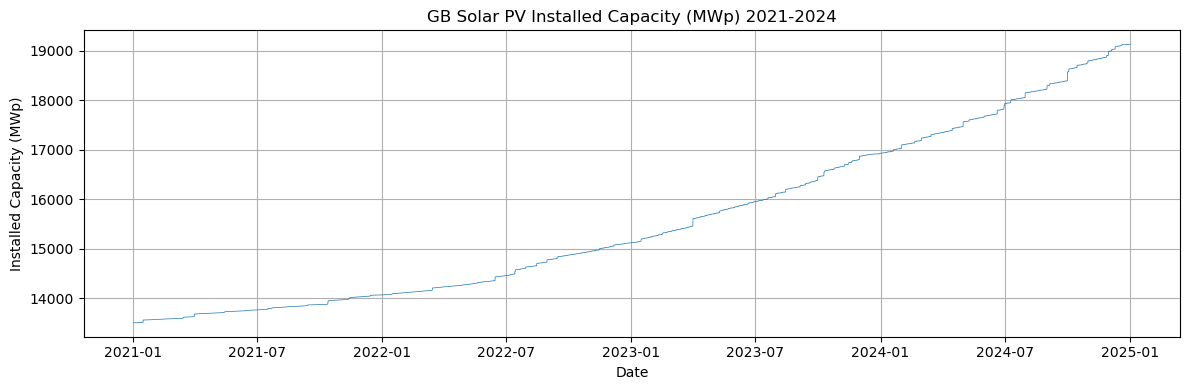

In [36]:
#Plot installed capacity over time
plt.figure(figsize=(12,4))
plt.plot(pv_hourly.index, pv_hourly['capacity_mwp'], linewidth=0.5)
plt.xlabel("Date")
plt.ylabel("Installed Capacity (MWp)")
plt.title("GB Solar PV Installed Capacity (MWp) 2021-2024")
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
#Save PV_Live hourly data to CSV
output_path = os.path.join(OUTPUT_DIR, "PV_Live_Hourly_2021 to 2024.csv")
pv_hourly.to_csv(output_path)
print(f"Saved: {output_path}")
print(f"Shape: {pv_hourly.shape}")
print(f"Rows: {len(pv_hourly)}")
print(f"Columns: {list(pv_hourly.columns)}")


Saved: C:\Users\emran\Desktop\UCL\Dissertation\Datasets\Processed\PV_Live_Hourly_2021 to 2024.csv
Shape: (35064, 5)
Rows: 35064
Columns: ['generation_mw', 'capacity_mwp', 'ucl_mw', 'lcl_mw', 'capacity_factor']


### ERA5 Preprocessing

In [ ]:
#ERA5 data preparation
ERA5_RAW_DIR = Path(r"C:\Users\emran\Desktop\UCL\Dissertation\Datasets\ERA5\era5_data_monthly")
ERA5_MERGED_DIR = Path(r"C:\Users\emran\Desktop\UCL\Dissertation\Datasets\ERA5\era5_merged")
ERA5_MERGED_DIR.mkdir(parents=True, exist_ok=True)

years = [2021, 2022, 2023, 2024]

for year in years:
    month_dirs = sorted(ERA5_RAW_DIR.glob(f"era5_gb_{year:04d}_??"))
    print(f"{year}: {len(month_dirs)} monthly folders found")

2021: 12 monthly folders found
2022: 12 monthly folders found
2023: 12 monthly folders found
2024: 12 monthly folders found


In [47]:
#Merge monthly files into annual files (accum and instant separately)
step_types = ["accum", "instant"]

for year in years:
    annual_dir = ERA5_MERGED_DIR / f"era5_gb_{year:04d}"
    annual_dir.mkdir(parents=True, exist_ok=True)

    month_dirs = sorted(ERA5_RAW_DIR.glob(f"era5_gb_{year:04d}_??"))

    for step in step_types:
        monthly_files =[]
        for month_dir in month_dirs:
            candidate = month_dir / f"data_stream-oper_stepType-{step}.nc"
            if not candidate.exists():
                print(f"Warning: Missing file {candidate}")
                continue
            monthly_files.append(str(candidate))

        print(f"Merging year={year}, step={step}, files={len(monthly_files)}")
        with xr.open_mfdataset(monthly_files, combine='by_coords') as ds:
            output_path = annual_dir / f"data_stream-oper_stepType-{step}.nc"
            ds.to_netcdf(output_path)
            print(f"Merged file {output_path}")        

Merging year=2021, step=accum, files=12
Merged file C:\Users\emran\Desktop\UCL\Dissertation\Datasets\ERA5\era5_merged\era5_gb_2021\data_stream-oper_stepType-accum.nc
Merging year=2021, step=instant, files=12
Merged file C:\Users\emran\Desktop\UCL\Dissertation\Datasets\ERA5\era5_merged\era5_gb_2021\data_stream-oper_stepType-instant.nc
Merging year=2022, step=accum, files=12
Merged file C:\Users\emran\Desktop\UCL\Dissertation\Datasets\ERA5\era5_merged\era5_gb_2022\data_stream-oper_stepType-accum.nc
Merging year=2022, step=instant, files=12
Merged file C:\Users\emran\Desktop\UCL\Dissertation\Datasets\ERA5\era5_merged\era5_gb_2022\data_stream-oper_stepType-instant.nc
Merging year=2023, step=accum, files=12
Merged file C:\Users\emran\Desktop\UCL\Dissertation\Datasets\ERA5\era5_merged\era5_gb_2023\data_stream-oper_stepType-accum.nc
Merging year=2023, step=instant, files=12
Merged file C:\Users\emran\Desktop\UCL\Dissertation\Datasets\ERA5\era5_merged\era5_gb_2023\data_stream-oper_stepType-ins

In [ ]:
#Check variables inside files
check_year = years[0]
check_dir = ERA5_MERGED_DIR / f"era5_gb_{check_year:04d}"

for step in step_types:
    filepath = check_dir / f"data_stream-oper_stepType-{step}.nc"
    ds = xr.open_dataset(str(filepath))
    
    print(f"\n{step} file:")
    print(f"Variables: {list(ds.data_vars)}")
    print(f"Dimensions: {dict(ds.dims)}")
    print(f"Coordinates: {list(ds.coords)}")
    
    for var in ds.data_vars:
        print(f"{var}: {ds[var].attrs.get('long_name', 'no description')}")
    
    ds.close()


accum file:
Variables: ['ssr', 'ssrd', 'fdir']
Dimensions: {'valid_time': 8760, 'latitude': 39, 'longitude': 41}
Coordinates: ['number', 'valid_time', 'latitude', 'longitude', 'expver']
ssr: Surface net short-wave (solar) radiation
ssrd: Surface short-wave (solar) radiation downwards
fdir: Surface direct short-wave (solar) radiation

instant file:
Variables: ['u10', 'v10', 'd2m', 't2m', 'tcc']
Dimensions: {'valid_time': 8760, 'latitude': 39, 'longitude': 41}
Coordinates: ['number', 'valid_time', 'latitude', 'longitude', 'expver']
u10: 10 metre U wind component
v10: 10 metre V wind component
d2m: 2 metre dewpoint temperature
t2m: 2 metre temperature
tcc: Total cloud cover


C:\Users\emran\AppData\Local\Temp\ipykernel_42452\1048077983.py:10: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Dimensions: {dict(ds.dims)}")
C:\Users\emran\AppData\Local\Temp\ipykernel_42452\1048077983.py:10: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Dimensions: {dict(ds.dims)}")


In [51]:
#Merge accum and instant files into a single dataset for each year
for year in years:
    annual_dir = ERA5_MERGED_DIR / f"era5_gb_{year:04d}"

    accum_path = annual_dir / "data_stream-oper_stepType-accum.nc"
    instant_path = annual_dir / "data_stream-oper_stepType-instant.nc"

    print(f"Merging accum and instant for {year}...")

    ds_accum = xr.open_dataset(str(accum_path))
    ds_instant = xr.open_dataset(str(instant_path))
    ds_merged = xr.merge([ds_accum, ds_instant])

    output_path = ERA5_MERGED_DIR / f"era5_gb_{year:04d}.nc"
    ds_merged.to_netcdf(str(output_path))

    print(f"Variables: {list(ds_merged.data_vars)}")
    print(f"Total hours: {len(ds_merged.valid_time)}")
    print(f"Saved merged file: {output_path}")

    ds_accum.close()
    ds_instant.close()
    ds_merged.close()


Merging accum and instant for 2021...
Variables: ['ssr', 'ssrd', 'fdir', 'u10', 'v10', 'd2m', 't2m', 'tcc']
Total hours: 8760
Saved merged file: C:\Users\emran\Desktop\UCL\Dissertation\Datasets\ERA5\era5_merged\era5_gb_2021.nc
Merging accum and instant for 2022...
Variables: ['ssr', 'ssrd', 'fdir', 'd2m', 't2m', 'u10', 'v10', 'tcc']
Total hours: 8760
Saved merged file: C:\Users\emran\Desktop\UCL\Dissertation\Datasets\ERA5\era5_merged\era5_gb_2022.nc
Merging accum and instant for 2023...
Variables: ['ssr', 'ssrd', 'fdir', 'd2m', 't2m', 'u10', 'v10', 'tcc']
Total hours: 8760
Saved merged file: C:\Users\emran\Desktop\UCL\Dissertation\Datasets\ERA5\era5_merged\era5_gb_2023.nc
Merging accum and instant for 2024...
Variables: ['ssr', 'ssrd', 'fdir', 'd2m', 't2m', 'u10', 'v10', 'tcc']
Total hours: 8784
Saved merged file: C:\Users\emran\Desktop\UCL\Dissertation\Datasets\ERA5\era5_merged\era5_gb_2024.nc


In [53]:
#Verify merged files
exp_vars = ['ssr', 'ssrd', 'fdir', 'u10', 'v10', 'd2m', 't2m', 'tcc']

for year in years:
    filepath = ERA5_MERGED_DIR / f"era5_gb_{year:04d}.nc"
    ds=xr.open_dataset(str(filepath))

    act_vars = [v.lower() for v in ds.data_vars]
    print(f"\n{year}: {filepath.name}")
    for var in exp_vars:
        found = var in act_vars
        status = "FOUND" if found else "MISSING"
        print(f" {status}: {var}")

    print(f" Hours: {len(ds.valid_time)}")
    print(f" Time range: {str(ds.valid_time.values[0])[:19]} to {str(ds.valid_time.values[-1])[:19]}")
    ds.close()


2021: era5_gb_2021.nc
 FOUND: ssr
 FOUND: ssrd
 FOUND: fdir
 FOUND: u10
 FOUND: v10
 FOUND: d2m
 FOUND: t2m
 FOUND: tcc
 Hours: 8760
 Time range: 2021-01-01T00:00:00 to 2021-12-31T23:00:00

2022: era5_gb_2022.nc
 FOUND: ssr
 FOUND: ssrd
 FOUND: fdir
 FOUND: u10
 FOUND: v10
 FOUND: d2m
 FOUND: t2m
 FOUND: tcc
 Hours: 8760
 Time range: 2022-01-01T00:00:00 to 2022-12-31T23:00:00

2023: era5_gb_2023.nc
 FOUND: ssr
 FOUND: ssrd
 FOUND: fdir
 FOUND: u10
 FOUND: v10
 FOUND: d2m
 FOUND: t2m
 FOUND: tcc
 Hours: 8760
 Time range: 2023-01-01T00:00:00 to 2023-12-31T23:00:00

2024: era5_gb_2024.nc
 FOUND: ssr
 FOUND: ssrd
 FOUND: fdir
 FOUND: u10
 FOUND: v10
 FOUND: d2m
 FOUND: t2m
 FOUND: tcc
 Hours: 8784
 Time range: 2024-01-01T00:00:00 to 2024-12-31T23:00:00


In [54]:
#Preprocessing pipeline
print(f"Update ERA5_DIR in preprocessing pipeline to:")
print(f" ERA5_DIR = r\"{ERA5_MERGED_DIR}\"")
print(f"\nFiles the pipeline will find:")
for f in sorted (ERA5_MERGED_DIR.glob("era5_gb_????.nc")):
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f" {f.name} ({size_mb:.1f} MB)")

Update ERA5_DIR in preprocessing pipeline to:
 ERA5_DIR = r"C:\Users\emran\Desktop\UCL\Dissertation\Datasets\ERA5\era5_merged"

Files the pipeline will find:
 era5_gb_2021.nc (170.4 MB)
 era5_gb_2022.nc (170.9 MB)
 era5_gb_2023.nc (169.7 MB)
 era5_gb_2024.nc (169.4 MB)


In [58]:
#Verify ERA5 files - preprocessing pipeline
era5_files = sorted([f for f in os.listdir(ERA5_DIR) if f.endswith('.nc')])

print(f"ERA5 folder path: {ERA5_DIR}")
print(f"Number of NetCDF files: {len(era5_files)}")
print()
for f in era5_files:
    size_mb = os.path.getsize(os.path.join(ERA5_DIR, f)) / (1024 * 1024)
    print(f"{f} ({size_mb:.1f} MB)")

ERA5 folder path: C:\Users\emran\Desktop\UCL\Dissertation\Datasets\ERA5\era5_merged
Number of NetCDF files: 4

era5_gb_2021.nc (170.4 MB)
era5_gb_2022.nc (170.9 MB)
era5_gb_2023.nc (169.7 MB)
era5_gb_2024.nc (169.4 MB)


In [65]:
#Check units for each variable
ds = xr.open_dataset(os.path.join(ERA5_DIR, era5_files[0]))

print(f"File_name: {era5_files[0]}")
print(f"\nVariables:")
for var in ds.data_vars:
    shape = ds[var].shape
    units = ds[var].attrs.get('units', 'no units')
    long_name = ds[var].attrs.get('long_name', 'no description')
    print(f" {var}: shape={shape}, units ={units}")
    print(f"  {long_name}")

print(f"\nDimensions:")
print(f" valid_time: {len(ds.valid_time)} hours")
print(f" time range: {str(ds.valid_time.values[0])[:19]} to {str(ds.valid_time.values[-1])[:19]}")
print(f" latitude: {float(ds.latitude.min()):.1f} to {float(ds.latitude.max()):.1f}")
print(f" longitude: {float(ds.longitude.min()):.1f} to {float(ds.longitude.max()):.1f}")

ds.close()

File_name: era5_gb_2021.nc

Variables:
 ssr: shape=(8760, 39, 41), units =J m**-2
  Surface net short-wave (solar) radiation
 ssrd: shape=(8760, 39, 41), units =J m**-2
  Surface short-wave (solar) radiation downwards
 fdir: shape=(8760, 39, 41), units =J m**-2
  Surface direct short-wave (solar) radiation
 u10: shape=(8760, 39, 41), units =m s**-1
  10 metre U wind component
 v10: shape=(8760, 39, 41), units =m s**-1
  10 metre V wind component
 d2m: shape=(8760, 39, 41), units =K
  2 metre dewpoint temperature
 t2m: shape=(8760, 39, 41), units =K
  2 metre temperature
 tcc: shape=(8760, 39, 41), units =(0 - 1)
  Total cloud cover

Dimensions:
 valid_time: 8760 hours
 time range: 2021-01-01T00:00:00 to 2021-12-31T23:00:00
 latitude: 49.5 to 59.0
 longitude: -8.0 to 2.0


Decreased time value from one hour to another: 15 out of 71
Values are up and down (hourly accumulation).
Divide by 3600 to get W/m2. No differencing needed.


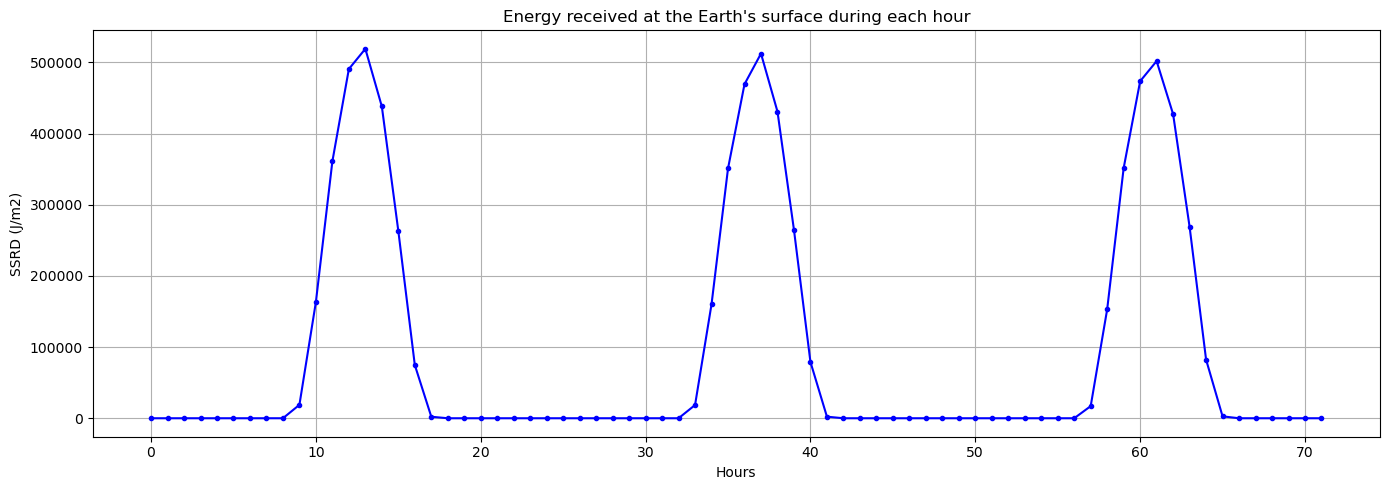

In [74]:
ds = xr.open_dataset(os.path.join(ERA5_DIR, era5_files[0]))

ssrd_mean = ds['ssrd'].mean(dim=['latitude', 'longitude'])
initial_72h = ssrd_mean.isel(valid_time=slice(0,72))

plt.figure(figsize=(14,5))
plt.plot(range(72), initial_72h, 'b-o', markersize=3)
plt.xlabel("Hours")
plt.ylabel("SSRD (J/m2)")
plt.grid(True)
plt.title("Energy received at the Earth's surface during each hour")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ERA5_Accumulation Check.png"), dpi = 150)

val = initial_72h.values
dec = np.sum(np.diff(val) < 0)
print(f"Decreased time value from one hour to another: {dec} out of {len(val)-1}")

if dec > 10:
    print("Values are up and down (hourly accumulation).")
    print("Divide by 3600 to get W/m2. No differencing needed.")
else:
    print("Values mostly increase. Run accumulation.")
    print("First need to difference consecutive timesteps first, then divide by 3600.")

ds.close()            

In [76]:
#Set de-accumulation record
REQUIRES_DIFFERENCING = False
print("Hourly accumulation confirmed")
print("Divide radiation variables by 3600 to convert J/m2 to W/m2")

Hourly accumulation confirmed
Divide radiation variables by 3600 to convert J/m2 to W/m2


In [77]:
#Test spatial averaging for year 2021
ds = xr.open_dataset(os.path.join(ERA5_DIR, era5_files[0]))
print(f"Processing: {era5_files[0]}")
print(f"Data shape before averaging: {ds['ssrd'].shape}")

#Cosine latitude weighting
latitude_weight = np.cos(np.deg2rad(ds.latitude))
latitude_weight = latitude_weight / latitude_weight.sum()

#Average across grid points
ds_avg = ds.weighted(latitude_weight).mean(dim=['latitude','longitude'])

df_test = ds_avg.to_dataframe()

print(f"\nData shape after averaging: {df_test.shape}")
print(f"Columns: {list(df_test.columns)}")
print(f"\nFirst 10 rows:")
print(df_test.head(10))
print(f"\nLast 10 rows:")
print(df_test.tail(10))

ds.close()


Processing: era5_gb_2021.nc
Data shape before averaging: (8760, 39, 41)

Data shape after averaging: (8760, 10)
Columns: ['number', 'expver', 'ssr', 'ssrd', 'fdir', 'u10', 'v10', 'd2m', 't2m', 'tcc']

First 10 rows:
                     number expver           ssr          ssrd         fdir  \
valid_time                                                                    
2021-01-01 00:00:00       0   0001  3.599999e-12      0.000000     0.000000   
2021-01-01 01:00:00       0   0001  3.599999e-12      0.000000     0.000000   
2021-01-01 02:00:00       0   0001  3.599999e-12      0.000000     0.000000   
2021-01-01 03:00:00       0   0001  3.599999e-12      0.000000     0.000000   
2021-01-01 04:00:00       0   0001  3.599999e-12      0.000000     0.000000   
2021-01-01 05:00:00       0   0001  3.599999e-12      0.000000     0.000000   
2021-01-01 06:00:00       0   0001  3.599999e-12      0.000000     0.000000   
2021-01-01 07:00:00       0   0001  3.599999e-12      0.000000     0.0000

In [78]:
#Convert radiation and temperature 
df_convert = df_test.copy()

df_convert = df_convert.drop(columns=['number', 'expver'])
print(f"Remaining columns after dropping: {list(df_convert.columns)}")

rad_vars = ['ssr', 'ssrd', 'fdir']
for var in rad_vars:
    df_convert[var] = df_convert[var] / 3600.0
    df_convert[var] = df_convert[var].clip(lower=0)
print("Converted radiation - J/m2 to W/m2")

temp_vars = ['d2m', 't2m']
for var in temp_vars:
    df_convert[var] = df_convert[var] - 273.15
print("Converted temperature - K to deg C")

print(f"\nColumns: {list(df_convert.columns)}")
print(f"\nSample - January 1, 2021 (hours 8-14):")
print(df_convert.iloc[8:15].round(2))

Remaining columns after dropping: ['ssr', 'ssrd', 'fdir', 'u10', 'v10', 'd2m', 't2m', 'tcc']
Converted radiation - J/m2 to W/m2
Converted temperature - K to deg C

Columns: ['ssr', 'ssrd', 'fdir', 'u10', 'v10', 'd2m', 't2m', 'tcc']

Sample - January 1, 2021 (hours 8-14):
                        ssr    ssrd   fdir   u10   v10   d2m   t2m   tcc
valid_time                                                              
2021-01-01 08:00:00    0.00    0.00   0.00  0.44 -6.16  1.71  4.11  0.56
2021-01-01 09:00:00    4.89    5.58   1.66  0.52 -6.05  1.72  4.11  0.55
2021-01-01 10:00:00   40.58   46.93  19.15  0.58 -6.00  1.87  4.36  0.56
2021-01-01 11:00:00   88.60  102.26  50.45  0.73 -6.00  2.00  4.64  0.57
2021-01-01 12:00:00  120.70  138.63  73.92  0.82 -6.04  2.08  4.90  0.56
2021-01-01 13:00:00  127.45  146.32  81.18  0.95 -6.09  2.12  5.06  0.58
2021-01-01 14:00:00  107.37  123.63  66.39  1.01 -6.08  2.12  5.16  0.61


In [81]:
#Verify units
#Radiation
for var in ['ssr', 'ssrd', 'fdir']:
    vmin = df_convert[var].min()
    vmax = df_convert[var].max()
    neg = (df_convert[var] < 0).sum()
    status = "Correct" if vmin >= 0 and vmax < 1200 else "Wrong"
    print(f" {status} {var}: {vmin:.2f} to {vmax:.2f} W/m2, negatives: {neg}")

#Temperature
for var in ['d2m', 't2m']:
    vmin = df_convert[var].min()
    vmax = df_convert[var].max()
    status = "Correct" if vmin > -20 and vmax < 45 else "Wrong"
    print(f" {status} {var}: {vmin:.2f} to {vmax:.2f} deg C")

#Cloud cover
vmin = df_convert['tcc'].min()
vmax = df_convert['tcc'].max()
status = "Correct" if vmin >= 0 and vmax <= 1.01 else "Wrong"
print(f" {status} tcc: {vmin:.3f} to {vmax:.3f}")

#Wind
for var in ['v10', 'u10']:
    vmin = df_convert[var].min()
    vmax = df_convert[var].max()
    status = "Correct" if abs(vmin) < 30 and abs(vmax) < 30 else "Wrong"
    print(f" {status} {var}: {vmin:.2f} to {vmax:.2f} m/s")

#Nan check
nan_sum = df_convert.isna().sum().sum()
print(f"\n {'OK' if nan_sum == 0 else 'Warning'} Total NaN values: {nan_sum}")
    

 Correct ssr: 0.00 to 725.04 W/m2, negatives: 0
 Correct ssrd: 0.00 to 802.38 W/m2, negatives: 0
 Correct fdir: 0.00 to 631.66 W/m2, negatives: 0
 Correct d2m: -5.11 to 15.83 deg C
 Correct t2m: -0.15 to 20.63 deg C
 Correct tcc: 0.146 to 1.000
 Correct v10: -12.90 to 12.34 m/s
 Correct u10: -8.66 to 11.54 m/s

 OK Total NaN values: 0


In [89]:
#Processing ERA5 data from 2021-2024
era5_yearly = []

for fname in era5_files:
    filepath = os.path.join(ERA5_DIR, fname)
    print(f"Processing {fname}..")

    ds = xr.open_dataset(filepath)

    latitude_weight = np.cos(np.deg2rad(ds.latitude))
    latitude_weight = latitude_weight / latitude_weight.sum()
    ds_avg = ds.weighted(latitude_weight).mean(dim=['latitude', 'longitude'])

    df = ds_avg.to_dataframe()
    cols_drop = [col for col in ['number', 'expver'] if col in df.columns]
    df = df.drop(columns=cols_drop)

    for var in ['ssr', 'ssrd', 'fdir']:
        df[var] = df[var] / 3600.0
        df[var] = df[var].clip(lower=0)
                               
    for var in ['d2m', 't2m']:
        df[var] = df[var] - 273.15
    
    era5_yearly.append(df)
    ds.close()
    print(f" Complete: {len(df)} rows, columns: {list(df.columns)}")

#Combine all years
era5 = pd.concat(era5_yearly)
era5.index = pd.to_datetime(era5.index, utc=True)
era5 = era5.sort_index ()

#Remove duplicates
before = len(era5)
era5 = era5[era5.index.duplicated(keep='first') == False]
after = len(era5)
if before != after:
    print(f" {before - after} duplicated timesteps removed")

#Rearrange columns
era5 = era5[['ssr', 'ssrd', 'fdir', 'd2m', 't2m', 'u10', 'v10', 'tcc']]

print(f"\nFinal ERA5 dataset: {era5.shape}")
print(f"Columns: {list(era5.columns)}")
print(f"Data range: {era5.index.min()} to {era5.index.max()}")

Processing era5_gb_2021.nc..
 Complete: 8760 rows, columns: ['ssr', 'ssrd', 'fdir', 'u10', 'v10', 'd2m', 't2m', 'tcc']
Processing era5_gb_2022.nc..
 Complete: 8760 rows, columns: ['ssr', 'ssrd', 'fdir', 'd2m', 't2m', 'u10', 'v10', 'tcc']
Processing era5_gb_2023.nc..
 Complete: 8760 rows, columns: ['ssr', 'ssrd', 'fdir', 'd2m', 't2m', 'u10', 'v10', 'tcc']
Processing era5_gb_2024.nc..
 Complete: 8784 rows, columns: ['ssr', 'ssrd', 'fdir', 'd2m', 't2m', 'u10', 'v10', 'tcc']

Final ERA5 dataset: (35064, 8)
Columns: ['ssr', 'ssrd', 'fdir', 'd2m', 't2m', 'u10', 'v10', 'tcc']
Data range: 2021-01-01 00:00:00+00:00 to 2024-12-31 23:00:00+00:00


In [90]:
#Verify units - ERA5 data 2021 to 2024
#Radiation
for var in ['ssr', 'ssrd', 'fdir']:
    vmin = era5[var].min()
    vmax = era5[var].max()
    neg = (era5[var] < 0).sum()
    status = "Correct" if vmin >= 0 and vmax < 1200 else "Wrong"
    print(f" {status} {var}: {vmin:.2f} to {vmax:.2f} W/m2, negatives: {neg}")

#Temperature
for var in ['d2m', 't2m']:
    vmin = era5[var].min()
    vmax = era5[var].max()
    status = "Correct" if vmin > -20 and vmax < 45 else "Wrong"
    print(f" {status} {var}: {vmin:.2f} to {vmax:.2f} deg C")

#Cloud cover
vmin = era5['tcc'].min()
vmax = era5['tcc'].max()
status = "Correct" if vmin >= 0 and vmax <= 1.01 else "Wrong"
print(f" {status} tcc: {vmin:.3f} to {vmax:.3f}")

#Wind
for var in ['u10', 'v10']:
    vmin = era5[var].min()
    vmax = era5[var].max()
    status = "Correct" if abs(vmin) < 30 and abs(vmax) < 30 else "Wrong"
    print(f" {status} {var}: {vmin:.2f} to {vmax:.2f} m/s")

#Nan check
nan_sum = era5.isna().sum().sum()
print(f"\n {'OK' if nan_sum == 0 else 'Warning'} Total NaN values: {nan_sum}")

print(f"\n Total rows: {len(era5)}")
print(f" Expected: 35064 hours")
print(f" {'OK' if len(era5) == 35064 else 'Warning'} Match: {len(era5) == 35064}")

 Correct ssr: 0.00 to 756.54 W/m2, negatives: 0
 Correct ssrd: 0.00 to 836.13 W/m2, negatives: 0
 Correct fdir: 0.00 to 702.73 W/m2, negatives: 0
 Correct d2m: -5.11 to 17.29 deg C
 Correct t2m: -0.15 to 22.93 deg C
 Correct tcc: 0.037 to 1.000
 Correct u10: -9.14 to 13.52 m/s
 Correct v10: -12.90 to 14.03 m/s

 OK Total NaN values: 0

 Total rows: 35064
 Expected: 35064 hours
 OK Match: True


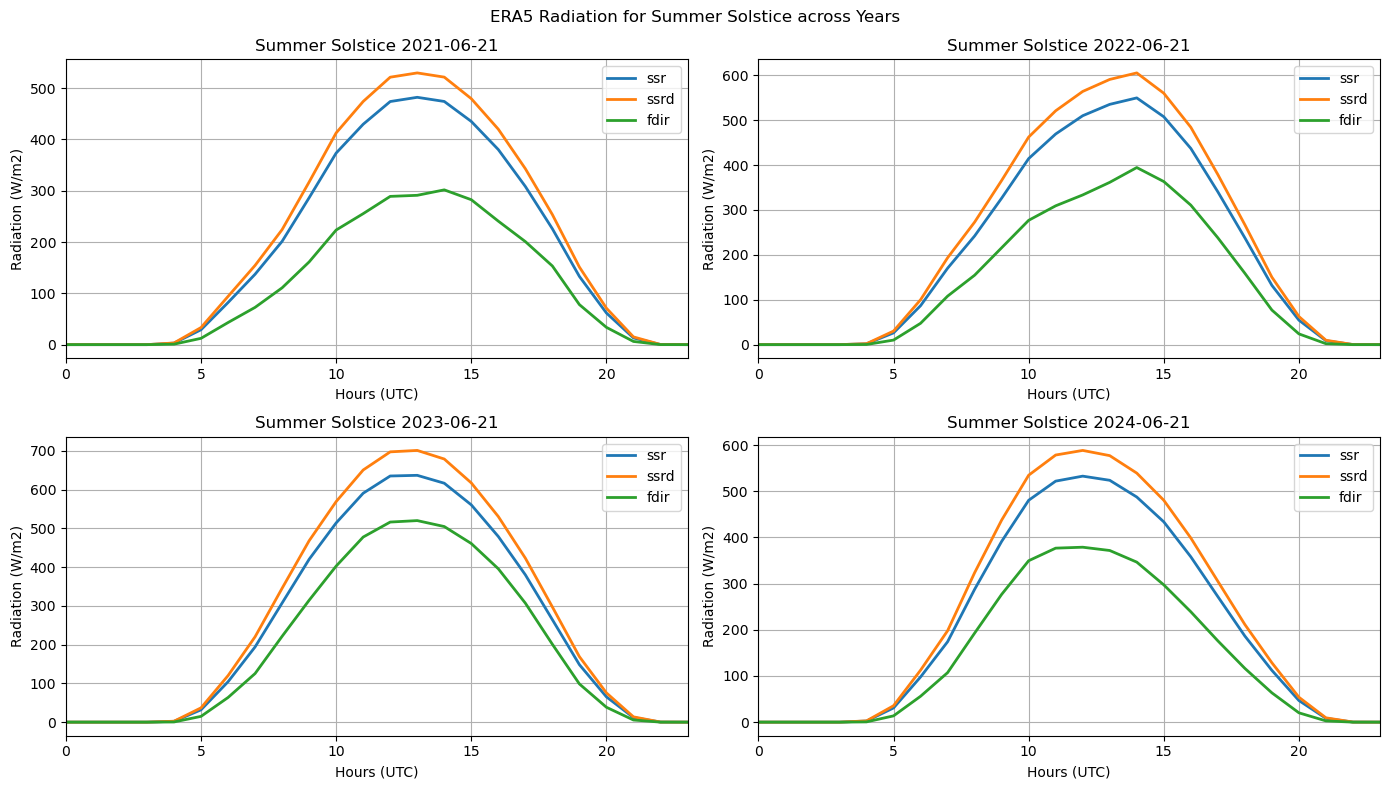

In [92]:
#Plot radiation for summer solstice - 2021 to 2024
fig, axes = plt.subplots (2, 2, figsize=(14,8))
axes = axes.flatten()

sols_dates = ['2021-06-21', '2022-06-21', '2023-06-21', '2024-06-21']

for i, date in enumerate(sols_dates):
    day_data = era5.loc[date]
    axes[i].plot(day_data.index.hour, day_data['ssr'], label='ssr', linewidth=2)
    axes[i].plot(day_data.index.hour, day_data['ssrd'], label='ssrd', linewidth=2)
    axes[i].plot(day_data.index.hour, day_data['fdir'], label='fdir', linewidth=2)
    axes[i].set_title(f"Summer Solstice {date}")
    axes[i].set_xlabel("Hours (UTC)")
    axes[i].set_ylabel("Radiation (W/m2)")
    axes[i].legend()
    axes[i].grid(True)
    axes[i].set_xlim(0,23)

plt.suptitle("ERA5 Radiation for Summer Solstice across Years")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "era5 radiation for summer solstice across years.png"), dpi=150)
plt.show()

In [103]:
#Range checks for variables
ssrd_check = (era5['ssr'] > era5['ssrd']).sum()
print(f"SSRD >= SSR check: {ssrd_check}")

fdir_check = (era5['fdir'] > era5['ssrd']).sum()
print(f"SSRD >= FDIR check: {fdir_check}")

temp_check = (era5['d2m'] > era5['t2m']).sum()
print(f" t2m >= d2m check: {temp_check}")

total_check = ssrd_check + fdir_check + temp_check
print(f"\nTotal physical range violations: {total_check} out of {len(era5)} rows")

SSRD >= SSR check: 14196
SSRD >= FDIR check: 0
 t2m >= d2m check: 0

Total physical range violations: 14196 out of 35064 rows


In [104]:
#Check where the violation occurs and maximum difference
violations = era5[era5['ssr'] > era5['ssrd']]

max_violation_diff = (violations['ssr'] - violations['ssrd']).max()
print(f"Maximum violation difference: {max_violation_diff} W/m2")

print(f"\nSample violation rows:")
print(violations[['ssr', 'ssrd']].head(10))

Maximum violation difference: 3.743746674191224e-05 W/m2

Sample violation rows:
                                    ssr  ssrd
valid_time                                   
2021-01-01 00:00:00+00:00  9.999997e-16   0.0
2021-01-01 01:00:00+00:00  9.999997e-16   0.0
2021-01-01 02:00:00+00:00  9.999997e-16   0.0
2021-01-01 03:00:00+00:00  9.999997e-16   0.0
2021-01-01 04:00:00+00:00  9.999997e-16   0.0
2021-01-01 05:00:00+00:00  9.999997e-16   0.0
2021-01-01 06:00:00+00:00  9.999997e-16   0.0
2021-01-01 07:00:00+00:00  9.999997e-16   0.0
2021-01-01 18:00:00+00:00  9.999997e-16   0.0
2021-01-01 19:00:00+00:00  9.999997e-16   0.0


In [105]:
#Range checks for variables (0.01 W/m2 tolerance for floating point noise)
ssrd_check = ((era5['ssr'] - era5['ssrd']) > 0.01).sum()
print(f"SSRD >= SSR check: {ssrd_check}")

fdir_check = ((era5['fdir'] - era5['ssrd']) > 0.01).sum()
print(f"SSRD >= FDIR check: {fdir_check}")

temp_check = (era5['d2m'] > era5['t2m']).sum()
print(f" t2m >= d2m check: {temp_check}")

total_check = ssrd_check + fdir_check + temp_check
print(f"\nTotal physical range violations: {total_check} out of {len(era5)} rows")

SSRD >= SSR check: 0
SSRD >= FDIR check: 0
 t2m >= d2m check: 0

Total physical range violations: 0 out of 35064 rows


In [108]:
#Save ERA5 hourly data to CSV
era5_path = os.path.join(OUTPUT_DIR, "ERA5_Hourly_2021 to 2024.csv")
era5.to_csv(era5_path)

print(f"Saved: {era5_path}")
print(f"Shape: {era5.shape}")
print(f"Rows: {len(era5)}")
print(f"Columns: {list(era5.columns)}")
print(f"Date range: {era5.index.min()} to {era5.index.max()}")

Saved: C:\Users\emran\Desktop\UCL\Dissertation\Datasets\Processed\ERA5_Hourly_2021 to 2024.csv
Shape: (35064, 8)
Rows: 35064
Columns: ['ssr', 'ssrd', 'fdir', 'd2m', 't2m', 'u10', 'v10', 'tcc']
Date range: 2021-01-01 00:00:00+00:00 to 2024-12-31 23:00:00+00:00


### BMRS Preprocessing

In [111]:
#BMRS data preparation
bmrs_dir = os.path.join(BASE_DIR, "BMRS")
bmrs_files = sorted([files for files in os.listdir(bmrs_dir) if files.endswith('.csv')])

print(f"BMRS filepath: {bmrs_dir}")
print(f"No. of CSV files: {len(bmrs_files)}")
for files in bmrs_files:
    print(f" {files}")

#Test 2021 file
df_bmrs_test = pd.read_csv(os.path.join(bmrs_dir, bmrs_files[0]))
print(f"\nFirst file: {bmrs_files[0]}")
print(f"File shape: {df_bmrs_test.shape}")
print(f"\nColumns: {list(df_bmrs_test.columns)}")
print(f"\nData types:\n{df_bmrs_test.dtypes}")
print(f"\nFirst 10 rows:")
df_bmrs_test.head(10)

BMRS filepath: C:\Users\emran\Desktop\UCL\Dissertation\Datasets\BMRS
No. of CSV files: 4
 BMRS Generation Mix (Elexon)_2021-01-01T00_00_2021-12-31T23_30.csv
 BMRS Generation Mix (Elexon)_2022-01-01T00_00_2022-12-31T23_30.csv
 BMRS Generation Mix (Elexon)_2023-01-01T00_00_2023-12-31T23_30.csv
 BMRS Generation Mix (Elexon)_2024-01-01T00_00_2024-12-31T23_30.csv

First file: BMRS Generation Mix (Elexon)_2021-01-01T00_00_2021-12-31T23_30.csv
File shape: (301526, 7)

Columns: ['Dataset', 'PublishTime', 'StartTime', 'SettlementDate', 'SettlementPeriod', 'FuelType', 'Generation']

Data types:
Dataset             object
PublishTime         object
StartTime           object
SettlementDate      object
SettlementPeriod     int64
FuelType            object
Generation           int64
dtype: object

First 10 rows:


,Dataset,PublishTime,StartTime,SettlementDate,SettlementPeriod,FuelType,Generation
0,FUELHH,2021-01-07T23:30:00Z,2021-01-07T23:00:00Z,2021-01-07,47,BIOMASS,2080
1,FUELHH,2021-01-07T23:30:00Z,2021-01-07T23:00:00Z,2021-01-07,47,CCGT,17310
2,FUELHH,2021-01-07T23:30:00Z,2021-01-07T23:00:00Z,2021-01-07,47,COAL,2255
3,FUELHH,2021-01-07T23:30:00Z,2021-01-07T23:00:00Z,2021-01-07,47,INTEW,0
4,FUELHH,2021-01-07T23:30:00Z,2021-01-07T23:00:00Z,2021-01-07,47,INTFR,70
5,FUELHH,2021-01-07T23:30:00Z,2021-01-07T23:00:00Z,2021-01-07,47,INTIFA2,0
6,FUELHH,2021-01-07T23:30:00Z,2021-01-07T23:00:00Z,2021-01-07,47,INTIRL,146
7,FUELHH,2021-01-07T23:30:00Z,2021-01-07T23:00:00Z,2021-01-07,47,INTNED,0
8,FUELHH,2021-01-07T23:30:00Z,2021-01-07T23:00:00Z,2021-01-07,47,INTNEM,678
9,FUELHH,2021-01-07T23:30:00Z,2021-01-07T23:00:00Z,2021-01-07,47,NPSHYD,307


In [113]:
#Identify all fuel types
all_fuels = set()
for files in bmrs_files:
    df_check = pd.read_csv(os.path.join(bmrs_dir, files), usecols=['FuelType'])
    all_fuels.update(df_check['FuelType'].unique())

all_fuels = sorted(all_fuels)
print(f"Total unique fuel types: {len(all_fuels)}")
print(f"\n All fuel types:")
for fuel in all_fuels:
    print(f" {fuel}")

#Identify interconnectors
inter = [fuel for fuel in all_fuels if fuel.startswith('INT')]
dom = [fuel for fuel in all_fuels if not fuel.startswith('INT')]

print(f"\nInterconnectors ({len(inter)}):")
for fuel in inter:
    print(f" {fuel}")

print(f"\nDomestic ({len(dom)}):")
for fuel in dom:
    print(f" {fuel}")


Total unique fuel types: 21

 All fuel types:
 BIOMASS
 CCGT
 COAL
 INTELE
 INTELEC
 INTEW
 INTFR
 INTGRNL
 INTIFA2
 INTIRL
 INTNED
 INTNEM
 INTNSL
 INTVKL
 NPSHYD
 NUCLEAR
 OCGT
 OIL
 OTHER
 PS
 WIND

Interconnectors (11):
 INTELE
 INTELEC
 INTEW
 INTFR
 INTGRNL
 INTIFA2
 INTIRL
 INTNED
 INTNEM
 INTNSL
 INTVKL

Domestic (10):
 BIOMASS
 CCGT
 COAL
 NPSHYD
 NUCLEAR
 OCGT
 OIL
 OTHER
 PS
 WIND


In [117]:
#Check data coverage and pivot file
df_bmrs_test['StartTime'] = pd.to_datetime(df_bmrs_test['StartTime'], utc=True)

print(f"Date range: {df_bmrs_test['StartTime'].min()} to {df_bmrs_test['StartTime'].max()}")
print(f"Total rows: {len(df_bmrs_test)}")

#Domestic only filter
df_dom = df_bmrs_test[df_bmrs_test['FuelType'].isin(dom)]
print(f"\nOnly domestic rows: {len(df_dom)}")
print(f"Kept fuel types: {sorted(df_dom['FuelType'].unique())}")

df_pivot = df_dom.pivot_table(
    index='StartTime',
    columns='FuelType',
    values='Generation',
    aggfunc='sum'
)

print(f"\nAfter pivot shape: {df_pivot.shape}")
print(f"Columns: {list(df_pivot.columns)}")
print(f"\nNan count per columns:")
print(df_pivot.isna().sum())

Date range: 2020-12-31 23:30:00+00:00 to 2021-12-31 23:00:00+00:00
Total rows: 301526

Only domestic rows: 175050
Kept fuel types: ['BIOMASS', 'CCGT', 'COAL', 'NPSHYD', 'NUCLEAR', 'OCGT', 'OIL', 'OTHER', 'PS', 'WIND']

After pivot shape: (17505, 10)
Columns: ['BIOMASS', 'CCGT', 'COAL', 'NPSHYD', 'NUCLEAR', 'OCGT', 'OIL', 'OTHER', 'PS', 'WIND']

Nan count per columns:
FuelType
BIOMASS    0
CCGT       0
COAL       0
NPSHYD     0
NUCLEAR    0
OCGT       0
OIL        0
OTHER      0
PS         0
WIND       0
dtype: int64


In [122]:
#Load all BMRS files
bmrs_all = []

for files in bmrs_files:
    df_temp = pd.read_csv(os.path.join(bmrs_dir, files))
    df_temp['StartTime'] = pd.to_datetime(df_temp['StartTime'], utc=True)

    df_temp = df_temp[df_temp['FuelType'].isin(dom)]

    df_pivot = df_temp.pivot_table(
        index='StartTime',
        columns='FuelType',
        values='Generation',
        aggfunc='sum'
    )
    bmrs_all.append(df_pivot)
    print(f"Processed {files}: {df_pivot.shape}")

#Merging all years
bmrs_pivot = pd.concat(bmrs_all)
bmrs_pivot = bmrs_pivot.sort_index()

#Trim to study period
bmrs_pivot = bmrs_pivot['2021-01-01': '2024-12-31']
print(f"\nMerged shape (half-hourly): {bmrs_pivot.shape} ")
print(f"Date range: {bmrs_pivot.index.min()} tp {bmrs_pivot.index.max()}")

#Extract wind and calculate domestic generation total
bmrs_hourly = pd.DataFrame()
bmrs_hourly['wind_generation_mw'] = bmrs_pivot['WIND'].resample('h').mean()
bmrs_hourly['total_generation_mw'] = bmrs_pivot.sum(axis=1).resample('h').mean()

print(f"\nShape after reasmpled (hourly): {bmrs_hourly.shape}")
print(f"Date range: {bmrs_hourly.index.min()} to {bmrs_hourly.index.max()}")
print(f"\nNan per column:")
print(bmrs_hourly.isna().sum())
print(f"\nFirst 10 rows:")
bmrs_hourly.head(10)

Processed BMRS Generation Mix (Elexon)_2021-01-01T00_00_2021-12-31T23_30.csv: (17505, 10)
Processed BMRS Generation Mix (Elexon)_2022-01-01T00_00_2022-12-31T23_30.csv: (17503, 10)
Processed BMRS Generation Mix (Elexon)_2023-01-01T00_00_2023-12-31T23_30.csv: (17518, 10)
Processed BMRS Generation Mix (Elexon)_2024-01-01T00_00_2024-12-31T23_30.csv: (17568, 10)

Merged shape (half-hourly): (70093, 10) 
Date range: 2021-01-01 00:00:00+00:00 tp 2024-12-31 23:00:00+00:00

Shape after reasmpled (hourly): (35064, 2)
Date range: 2021-01-01 00:00:00+00:00 to 2024-12-31 23:00:00+00:00

Nan per column:
wind_generation_mw     2
total_generation_mw    2
dtype: int64

First 10 rows:


,wind_generation_mw,total_generation_mw
StartTime,,
2021-01-01 00:00:00+00:00,4420.0,25459.0
2021-01-01 01:00:00+00:00,4261.5,24267.5
2021-01-01 02:00:00+00:00,4415.5,22697.0
2021-01-01 03:00:00+00:00,4404.0,21849.5
2021-01-01 04:00:00+00:00,4537.5,21062.0
2021-01-01 05:00:00+00:00,4718.0,20850.5
2021-01-01 06:00:00+00:00,4643.5,21591.5
2021-01-01 07:00:00+00:00,4759.0,22620.5
2021-01-01 08:00:00+00:00,4909.5,23736.5


In [ ]:
#Identify NaN
bmrs_nan = bmrs_hourly[bmrs_hourly.isna().any(axis=1)]
print(f"NaN rows: {len(bmrs_nan)}")
print(bmrs_nan)

#Show 3 rows before and after NaN
for index in bmrs_nan.index:
    position = bmrs_hourly.index.get_loc(index)
    start = max(0, position - 3)
    end = min(len(bmrs_hourly), position +4)
    print(f"\nContext around {index}:")
    print(bmrs_hourly.iloc[start:end])

NaN rows: 2
                           wind_generation_mw  total_generation_mw
StartTime                                                         
2021-11-23 13:00:00+00:00                 NaN                  NaN
2022-07-09 22:00:00+00:00                 NaN                  NaN

Context around 2021-11-23 13:00:00+00:00:
                           wind_generation_mw  total_generation_mw
StartTime                                                         
2021-11-23 10:00:00+00:00              2090.0              21872.5
2021-11-23 11:00:00+00:00                 0.0                  0.0
2021-11-23 12:00:00+00:00              1831.0              18393.0
2021-11-23 13:00:00+00:00                 NaN                  NaN
2021-11-23 14:00:00+00:00              3620.0              37120.0
2021-11-23 15:00:00+00:00              3872.5              37597.5
2021-11-23 16:00:00+00:00              3672.5              39084.5

Context around 2022-07-09 22:00:00+00:00:
                           wind

In [126]:
#Verify if these half-hourly timestamps exist in the pivoted data
check_times = [
    '2021-11-23 13:00', '2021-11-23 13:30',
    '2022-07-09 22:00', '2022-07-09 22:30'
]
for time in check_times:
    timestamp = pd.Timestamp(time, tz='UTC')
    exists = timestamp in bmrs_pivot.index
    print(f"{timestamp}: {'FOUND' if exists else 'MISSING'}")

2021-11-23 13:00:00+00:00: MISSING
2021-11-23 13:30:00+00:00: MISSING
2022-07-09 22:00:00+00:00: MISSING
2022-07-09 22:30:00+00:00: MISSING


In [129]:
#Check for implausibly of low total generation
low_threshold = 5000
low_generation = bmrs_hourly[bmrs_hourly['total_generation_mw'] < low_threshold]
print(f"Rows below {low_threshold} MW: {len(low_generation)}")
print(f"\nAll low generation rows:")
print(low_generation)

#Check for exact zeros
zero_rows = bmrs_hourly[bmrs_hourly['total_generation_mw'] == 0]
print(f"\nExact zero rows: {len(zero_rows)}")

Rows below 5000 MW: 13

All low generation rows:
                           wind_generation_mw  total_generation_mw
StartTime                                                         
2021-07-08 10:00:00+00:00                 0.0                  0.0
2021-11-23 11:00:00+00:00                 0.0                  0.0
2022-03-17 11:00:00+00:00              1639.0               4782.0
2022-05-24 10:00:00+00:00                 0.0                  0.0
2022-07-14 10:00:00+00:00               510.5               4392.0
2022-08-02 00:00:00+00:00                 0.0                  0.0
2023-06-07 10:00:00+00:00                 0.0                  0.0
2023-06-07 11:00:00+00:00                 0.0                  0.0
2023-09-28 10:00:00+00:00                 0.0                  0.0
2023-09-28 11:00:00+00:00                 0.0                  0.0
2024-01-23 11:00:00+00:00                 0.0                  0.0
2024-08-29 10:00:00+00:00               823.0               2868.5
2024-12-05 11

In [131]:
#Interpolate implausible and NaN rows 
#Replace implausible rows with NaN (below 5000MW threshold)
low_threshold = 5000
implausible_mask = bmrs_hourly['total_generation_mw'] < low_threshold
implausible_count = implausible_mask.sum()
print(f"Rows below {low_threshold} MW: {implausible_count}")

current_nan = bmrs_hourly.isna().any(axis=1).sum()
print(f"Current NaN rows: {current_nan}")

bmrs_hourly.loc[implausible_mask] = float('nan')

#Total NaN before interpolation
total_nan = bmrs_hourly.isna().any(axis=1).sum()
print(f"Total NaN rows required to interpolate: {total_nan}")

#Interpolate data
bmrs_hourly = bmrs_hourly.interpolate(method='linear')

#Check remaining NaN
unresolved_nan = bmrs_hourly.isna().sum().sum()
print(f"\nUnresolved NaN after interpolation: {unresolved_nan}")
print(f"Total rows: {len(bmrs_hourly)}")

#Show interpolated values for first implausible row
print(f"\nTime 2021-07-08 10:00:")
position = bmrs_hourly.index.get_loc(pd.Timestamp('2021-07-08 10:00', tz='UTC'))
print(bmrs_hourly.iloc[position-2:position+3])

Rows below 5000 MW: 13
Current NaN rows: 2
Total NaN rows required to interpolate: 15

Unresolved NaN after interpolation: 0
Total rows: 35064

Time 2021-07-08 10:00:
                           wind_generation_mw  total_generation_mw
StartTime                                                         
2021-07-08 08:00:00+00:00              1327.5              25806.5
2021-07-08 09:00:00+00:00               676.0              14834.5
2021-07-08 10:00:00+00:00               744.5              16818.5
2021-07-08 11:00:00+00:00               813.0              18802.5
2021-07-08 12:00:00+00:00              1149.0              25112.0


In [132]:
#Save BMRS hourly data to csv
bmrs_path = os.path.join(OUTPUT_DIR, "BMRS_Hourly_2021 to 2024.csv")
bmrs_hourly.to_csv(bmrs_path)

print(f"File saved: {bmrs_path}")
print(f"File shape: {bmrs_hourly.shape}")
print(f"Columns: {list(bmrs_hourly.columns)}")
print(f"Rows: {len(bmrs_hourly)}")
print(f"Date range: {bmrs_hourly.index.min()} to {bmrs_hourly.index.max()}")

File saved: C:\Users\emran\Desktop\UCL\Dissertation\Datasets\Processed\BMRS_Hourly_2021 to 2024.csv
File shape: (35064, 2)
Columns: ['wind_generation_mw', 'total_generation_mw']
Rows: 35064
Date range: 2021-01-01 00:00:00+00:00 to 2024-12-31 23:00:00+00:00


### Merging PV_Live, ERA5 and BMRS

In [ ]:
#Diagnostic check for all three files
pvlive = pd.read_csv(
    os.path.join(OUTPUT_DIR, "PV_Live_Hourly_2021 to 2024.csv"),
    index_col=0,
    parse_dates=True
)

era5 = pd.read_csv(
    os.path.join(OUTPUT_DIR, "ERA5_Hourly_2021 to 2024.csv"),
    index_col=0,
    parse_dates=True
)

bmrs = pd.read_csv(
    os.path.join(OUTPUT_DIR, "BMRS_Hourly_2021 to 2024.csv"),
    index_col=0,
    parse_dates=True
)

print(f"PV_Live: {pvlive.shape}, index name: {pvlive.index.name}, tz:{pvlive.index.tz}")
print(f"ERA5: {era5.shape}, index name: {era5.index.name}, tz: {era5.index.tz}")
print(f"BMRS: {bmrs.shape}, index name: {bmrs.index.name}, tz: {bmrs.index.tz}")

pvlive_era5_align = pvlive.index.equals(era5.index)
pvlive_bmrs_align = pvlive.index.equals(bmrs.index)
print(f"\nPV_Live index == ERA5 index: {pvlive_era5_align}")
print(f"PV_Live index == BMRS index: {pvlive_bmrs_align}")

PV_Live: (35064, 5), index name: datetime, tz:UTC
ERA5: (35064, 8), index name: valid_time, tz: UTC
BMRS: (35064, 2), index name: StartTime, tz: UTC

PV_Live index == ERA5 index: True
PV_Live index == BMRS index: True


In [135]:
#Check all columns
print(f"PV_Live columns: {list(pvlive.columns)}")
print(f"ERA5 columns: {list(era5.columns)}")
print(f"BMRS columns: {list(bmrs.columns)}")

PV_Live columns: ['generation_mw', 'capacity_mwp', 'ucl_mw', 'lcl_mw', 'capacity_factor']
ERA5 columns: ['ssr', 'ssrd', 'fdir', 'd2m', 't2m', 'u10', 'v10', 'tcc']
BMRS columns: ['wind_generation_mw', 'total_generation_mw']


In [138]:
#Merge all three datasets
df_merged = pd.concat([pvlive, era5, bmrs], axis=1)
df_merged.index.name = 'datetime'

print(f"Merged data shape: {df_merged.shape}")
print(f"Expected: (35064, 15)")
print(f"Rows: {len(df_merged)}")
print(f"Columns: {list(df_merged.columns)}")
print(f"Date range: {df_merged.index.min()} to {df_merged.index.max()}")
print(f"\nNaN per column:")
print(df_merged.isna().sum())
print(f"\nFirst 10 rows:")
df_merged.head(10)

Merged data shape: (35064, 15)
Expected: (35064, 15)
Rows: 35064
Columns: ['generation_mw', 'capacity_mwp', 'ucl_mw', 'lcl_mw', 'capacity_factor', 'ssr', 'ssrd', 'fdir', 'd2m', 't2m', 'u10', 'v10', 'tcc', 'wind_generation_mw', 'total_generation_mw']
Date range: 2021-01-01 00:00:00+00:00 to 2024-12-31 23:00:00+00:00

NaN per column:
generation_mw          0
capacity_mwp           0
ucl_mw                 0
lcl_mw                 0
capacity_factor        0
ssr                    0
ssrd                   0
fdir                   0
d2m                    0
t2m                    0
u10                    0
v10                    0
tcc                    0
wind_generation_mw     0
total_generation_mw    0
dtype: int64

First 10 rows:


,generation_mw,capacity_mwp,ucl_mw,lcl_mw,capacity_factor,ssr,ssrd,fdir,d2m,t2m,u10,v10,tcc,wind_generation_mw,total_generation_mw
datetime,,,,,,,,,,,,,,,
2021-01-01 00:00:00+00:00,0.0000,13503.179,0.000,0.0000,0.000000,9.999997e-16,0.000000,0.000000,1.726164,4.112052,0.004284,-5.771159,0.607257,4420.0,25459.0
2021-01-01 01:00:00+00:00,0.0000,13503.179,0.000,0.0000,0.000000,9.999997e-16,0.000000,0.000000,1.717294,4.089763,0.144848,-5.846747,0.598857,4261.5,24267.5
2021-01-01 02:00:00+00:00,0.0000,13503.179,0.000,0.0000,0.000000,9.999997e-16,0.000000,0.000000,1.681565,4.067575,0.238792,-5.971604,0.557975,4415.5,22697.0
2021-01-01 03:00:00+00:00,0.0000,13503.179,0.000,0.0000,0.000000,9.999997e-16,0.000000,0.000000,1.684365,4.055255,0.266277,-6.065745,0.576805,4404.0,21849.5
2021-01-01 04:00:00+00:00,0.0000,13503.179,0.000,0.0000,0.000000,9.999997e-16,0.000000,0.000000,1.678455,4.049535,0.298135,-6.160609,0.576124,4537.5,21062.0
2021-01-01 05:00:00+00:00,0.0000,13503.179,0.000,0.0000,0.000000,9.999997e-16,0.000000,0.000000,1.662085,4.026253,0.356022,-6.205675,0.601511,4718.0,20850.5
2021-01-01 06:00:00+00:00,0.0000,13503.179,0.000,0.0000,0.000000,9.999997e-16,0.000000,0.000000,1.677567,4.060459,0.392633,-6.240890,0.582613,4643.5,21591.5
2021-01-01 07:00:00+00:00,0.0000,13503.179,0.000,0.0000,0.000000,9.999997e-16,0.000000,0.000000,1.709944,4.092068,0.422699,-6.227193,0.563642,4759.0,22620.5
2021-01-01 08:00:00+00:00,0.0380,13503.179,0.045,0.0305,0.000003,5.181092e-04,0.000604,0.000025,1.708843,4.109070,0.443018,-6.156034,0.556773,4909.5,23736.5


In [164]:
#Calculate hourly renewable penetration percentage
#Formula: Renewable% = (PV_live solar + BMRS wind) / (PV_Live solar + BMRS total domestic) x 100
df_merged['renewables_pct'] = (
    (df_merged['generation_mw'] + df_merged['wind_generation_mw']) / (df_merged['generation_mw'] + df_merged['total_generation_mw']) * 100
)

print(f"Renewables % statistics:")
print(df_merged['renewables_pct'].describe())

#Check for problematic numbers
infinity_count = (df_merged['renewables_pct'] == float('inf')).sum()
nan_count = df_merged['renewables_pct'].isna().sum()
above100_values = (df_merged['renewables_pct'] > 100).sum()

print(f"\nInfinity values: {infinity_count}")
print(f"NaN values: {nan_count}")
print(f"Values above 100%: {above100_values}")

Renewables % statistics:
count    35064.000000
mean        31.869270
std         16.900853
min          0.511192
25%         18.187302
50%         30.198366
75%         44.860839
max         77.454391
Name: renewables_pct, dtype: float64

Infinity values: 0
NaN values: 0
Values above 100%: 0


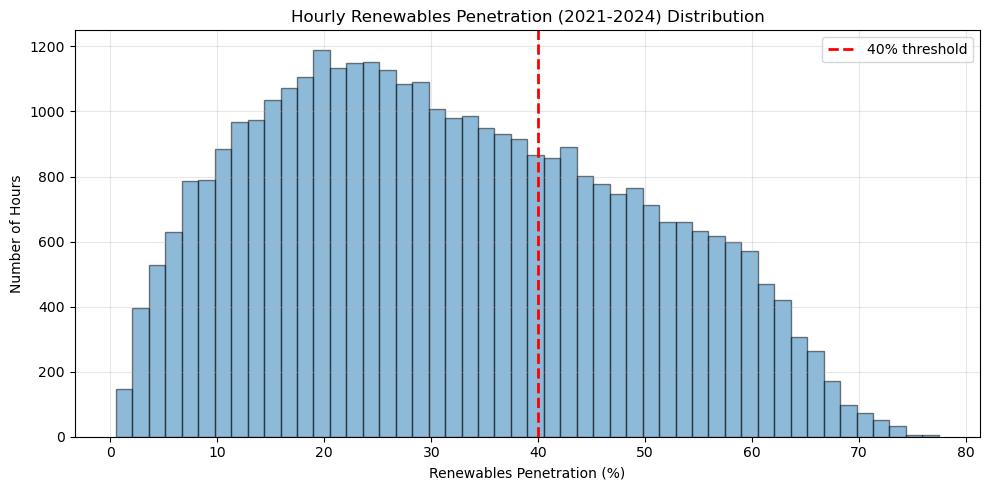

In [ ]:
#Histogram of renewables penetration
fig, ax = plt.subplots(figsize=(10,5))

ax.hist(df_merged['renewables_pct'], bins=50, edgecolor='black', alpha=0.5)
ax.axvline(x=40, color='red', linestyle='--', linewidth=2, label='40% threshold')
ax.set_xlabel('Renewables Penetration (%)')
ax.set_ylabel('Number of Hours')
ax.set_title('Hourly Renewables Penetration (2021-2024) Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Renewables Penetration Distribution.png"))
plt.show()

Hours per penetration regime:
regime
Low (<25%)           13827
Moderate (25-40%)     9775
High (> 40%)         11462
Name: count, dtype: int64

Total percentage:
regime
Low (<25%)           39.4
Moderate (25-40%)    27.9
High (> 40%)         32.7
Name: count, dtype: float64


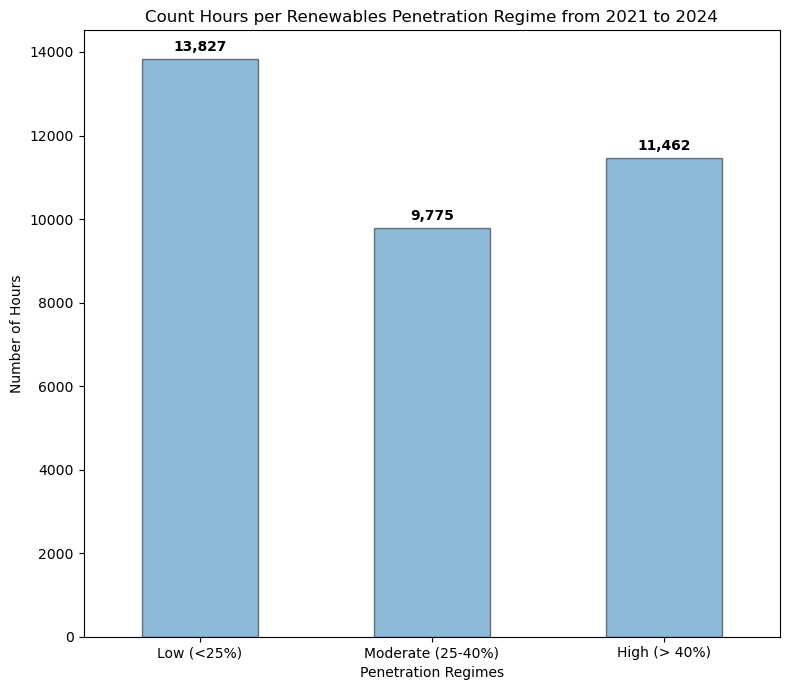

In [154]:
#Count hours per penetration regime
#Classify each hour into a penetration regime and count the samples in each
def classify_regime(pct):
    if pct < 25:
        return 'Low (<25%)'
    elif pct < 40:
        return 'Moderate (25-40%)'
    else:
        return 'High (> 40%)'
    
df_merged['regime'] = df_merged['renewables_pct'].apply(classify_regime)

regime_order = ['Low (<25%)', 'Moderate (25-40%)', 'High (> 40%)']
df_merged['regime'] = pd.Categorical(df_merged['regime'], categories=regime_order, ordered=True)

regime_count = df_merged['regime'].value_counts().sort_index()
print("Hours per penetration regime:")
print(regime_count)
print(f"\nTotal percentage:")
print((regime_count / len(df_merged) *100).round(1))

#Bar chart
fig, ax = plt.subplots(figsize=(8,7))
regime_count.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.5)
ax.set_xlabel('Penetration Regimes')
ax.set_ylabel('Number of Hours')
ax.set_title('Count Hours per Renewables Penetration Regime from 2021 to 2024')

for i, count in enumerate(regime_count):
    ax.text(i, count + 200, f"{count:,}", ha='center', fontweight='bold')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Count Hours per Penetration Regime.png"))
plt.show()

In [ ]:
#Save merged datasets. Dropping regime column. Can be regenerated later.
df_save = df_merged.drop(columns=['regime'])
merged_path = os.path.join(OUTPUT_DIR, "Merged Datasets_Hourly_2021 to 2024.csv")
df_save.to_csv(merged_path)

print(f"File saved: {merged_path}")
print(f"File shape: {df_save.shape}")
print(f"Rows: {len(df_save)}")
print(f"Columns: {list(df_save)}")
print(f"Date range: {df_save.index.min()} to {df_save.index.max()}")

File saved: C:\Users\emran\Desktop\UCL\Dissertation\Datasets\Processed\Merged Datasets_Hourly_2021 to 2024.csv
File shape: (35064, 16)
Rows: 35064
Columns: ['generation_mw', 'capacity_mwp', 'ucl_mw', 'lcl_mw', 'capacity_factor', 'ssr', 'ssrd', 'fdir', 'd2m', 't2m', 'u10', 'v10', 'tcc', 'wind_generation_mw', 'total_generation_mw', 'renewables_pct']
Date range: 2021-01-01 00:00:00+00:00 to 2024-12-31 23:00:00+00:00


In [ ]:
#Cyclical time encoding
#Hour of day
df_merged['hour_sin'] = np.sin(2 * np.pi * df_merged.index.hour / 24)
df_merged['hour_cos'] = np.cos(2 * np.pi * df_merged.index.hour / 24)

#Day of year
df_merged['doy_sin'] = np.sin(2 * np.pi * df_merged.index.dayofyear / 365.25)
df_merged['doy_cos'] = np.cos(2 * np.pi * df_merged.index.dayofyear / 365.25)

#Verify the ranges
for col in ['hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']:
    print(f"{col}: {df_merged[col].min():.4f} to {df_merged[col].max():.4f}")

print(f"\nData shape after encoding: {df_merged.shape}")

hour_sin: -1.0000 to 1.0000
hour_cos: -1.0000 to 1.0000
doy_sin: -1.0000 to 1.0000
doy_cos: -1.0000 to 1.0000

Data shape after encoding: (35064, 21)


In [172]:
#Calculate scalar wind speed from u and v components
df_merged['wind_speed'] = np.sqrt(df_merged['u10']**2 + df_merged['v10']**2)

print(f"Wind speed: {df_merged['wind_speed'].min():.4f} to {df_merged['wind_speed'].max():.4f} m/s")
print(f"Mean: {df_merged['wind_speed'].mean():.4f} m/s")
print(f"NaN: {df_merged['wind_speed'].isna().sum()}")
print(f"\nData shape after calculation: {df_merged.shape}")

Wind speed: 0.0355 to 15.6894 m/s
Mean: 4.9369 m/s
NaN: 0

Data shape after calculation: (35064, 22)


In [ ]:
#Check the columns present
print(f"Columns after dropping: {len(df_merged.columns)}")
print(f"Columns: {list(df_merged)}")

Columns after dropping: 22
Columns: ['generation_mw', 'capacity_mwp', 'ucl_mw', 'lcl_mw', 'capacity_factor', 'ssr', 'ssrd', 'fdir', 'd2m', 't2m', 'u10', 'v10', 'tcc', 'wind_generation_mw', 'total_generation_mw', 'renewables_pct', 'regime', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'wind_speed']


In [177]:
#Lag features
df_merged['lag_1h'] = df_merged['generation_mw'].shift(1)
df_merged['lag_24h'] = df_merged['generation_mw'].shift(24)

print(f"NaN for lag_1h: {df_merged['lag_1h'].isna().sum()}")
print(f"Nan for lag_24h: {df_merged['lag_24h'].isna().sum()}")
print(f"\nData shape after lag features: {df_merged.shape}")

#Verify if generation_mw at row 0 equals to lag_1h at row 1
print(f"\ngeneration_mw at row 0: {df_merged['generation_mw'].iloc[0]}")
print(f"lag_1h at row 1: {df_merged['lag_1h'].iloc[1]}")
print(f"Match: {df_merged['generation_mw'].iloc[0] == df_merged['lag_1h'].iloc[1]}")

NaN for lag_1h: 1
Nan for lag_24h: 24

Data shape after lag features: (35064, 24)

generation_mw at row 0: 0.0
lag_1h at row 1: 0.0
Match: True


In [180]:
#NaN summary
nan_summary = df_merged.isna().sum()
print(nan_summary[nan_summary > 0])

totalnan_rows = df_merged.isna().any(axis=1).sum()
print(f"\nTotal rows with any NaN: {totalnan_rows}")
print(f"Total rows: {len(df_merged)}")
print(f"Rows remaining after dropping: {len(df_merged) - totalnan_rows}")

lag_1h      1
lag_24h    24
dtype: int64

Total rows with any NaN: 24
Total rows: 35064
Rows remaining after dropping: 35040


In [185]:
#Dropping NaN rows from lag features
print(f"Rows before dropping: {len(df_merged)} rows")
df_final = df_merged.dropna(subset=['lag_1h', 'lag_24h'])
print(f"Rows after dropping: {len(df_final)} rows")

#Verify no NaN available
remaining_nan = df_final.isna().sum().sum()
print(f"\nRemaining NaN: {remaining_nan}")

#Save final dataset to csv
final_path = os.path.join(OUTPUT_DIR, "Final Dataset_Hourly_2021 to 2024.csv")
df_final.to_csv(final_path)
print(f"\nFile saved: {final_path}")
print(f"File shape: {df_final.shape}")
print(f"Columns: {len(df_final.columns)}")
print(f"Columns: {list(df_final)}")
print(f"Date range: {df_final.index.min()} to {df_final.index.max()}")

Rows before dropping: 35064 rows
Rows after dropping: 35040 rows

Remaining NaN: 0

File saved: C:\Users\emran\Desktop\UCL\Dissertation\Datasets\Processed\Final Dataset_Hourly_2021 to 2024.csv
File shape: (35040, 24)
Columns: 24
Columns: ['generation_mw', 'capacity_mwp', 'ucl_mw', 'lcl_mw', 'capacity_factor', 'ssr', 'ssrd', 'fdir', 'd2m', 't2m', 'u10', 'v10', 'tcc', 'wind_generation_mw', 'total_generation_mw', 'renewables_pct', 'regime', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'wind_speed', 'lag_1h', 'lag_24h']
Date range: 2021-01-02 00:00:00+00:00 to 2024-12-31 23:00:00+00:00


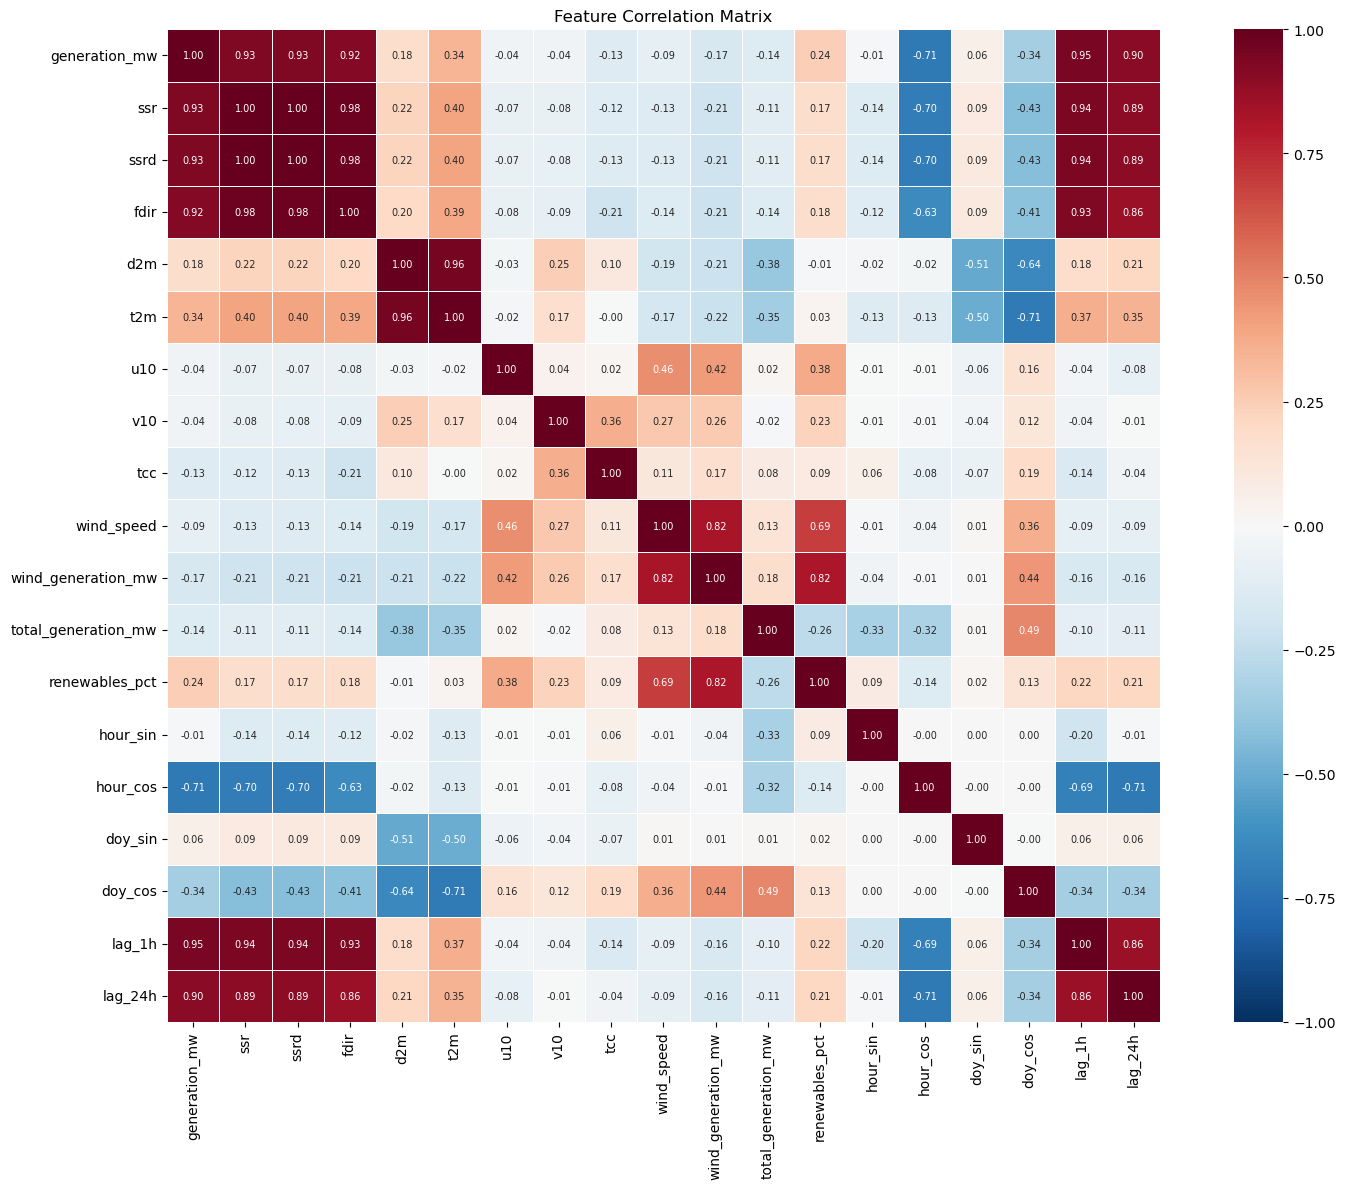


Correlations strongest with generation_mw:
 lag_1h: 0.953
 ssrd: 0.932
 ssr: 0.931
 fdir: 0.921
 lag_24h: 0.899
 t2m: 0.338
 renewables_pct: 0.243
 d2m: 0.179
 doy_sin: 0.062
 hour_sin: -0.012
 u10: -0.040
 v10: -0.044
 wind_speed: -0.093
 tcc: -0.132
 total_generation_mw: -0.137
 wind_generation_mw: -0.168
 doy_cos: -0.337
 hour_cos: -0.713


In [186]:
#Plot feature correlation matrix
import seaborn as sns
feature_cols = ['generation_mw', 'ssr', 'ssrd', 'fdir', 'd2m', 't2m', 'u10', 'v10', 'tcc', 
                'wind_speed', 'wind_generation_mw', 'total_generation_mw', 'renewables_pct', 
                'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'lag_1h', 'lag_24h']

corr_matrix = df_final[feature_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, square=True, ax=ax, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, center=0, 
             annot_kws={'size':7}, linewidth=0.7)
ax.set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Feature Correlation Matrix.png"), dpi=150)
plt.show()

print("\nCorrelations strongest with generation_mw:")
generation_corr = corr_matrix['generation_mw'].drop('generation_mw').sort_values(ascending=False)
for feature, value in generation_corr.items():
    print(f" {feature}: {value:.3f}")


In [2]:
BASE_DIR = r"C:\Users\emran\Desktop\UCL\Dissertation\Datasets"
OUTPUT_DIR = os.path.join(BASE_DIR, "Processed")

In [3]:
#Reload CSV after restarting kernel
df_finalrel = pd.read_csv(
    os.path.join(OUTPUT_DIR, "Final Dataset_Hourly_2021 to 2024.csv"),
    index_col=0, 
    parse_dates=True
)

print(f"Data shape loaded: {df_finalrel.shape}")
print(f"Columns: {list(df_finalrel.columns)}")
print(f"Date range: {df_finalrel.index.min()} to {df_finalrel.index.max()}")
print(f"NaN count: {df_finalrel.isna().sum().sum()}")
print(f"\nFirst 10 rows:")
(df_finalrel.head(10))

Data shape loaded: (35040, 24)
Columns: ['generation_mw', 'capacity_mwp', 'ucl_mw', 'lcl_mw', 'capacity_factor', 'ssr', 'ssrd', 'fdir', 'd2m', 't2m', 'u10', 'v10', 'tcc', 'wind_generation_mw', 'total_generation_mw', 'renewables_pct', 'regime', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'wind_speed', 'lag_1h', 'lag_24h']
Date range: 2021-01-02 00:00:00+00:00 to 2024-12-31 23:00:00+00:00
NaN count: 0

First 10 rows:


,generation_mw,capacity_mwp,ucl_mw,lcl_mw,capacity_factor,ssr,ssrd,fdir,d2m,t2m,...,total_generation_mw,renewables_pct,regime,hour_sin,hour_cos,doy_sin,doy_cos,wind_speed,lag_1h,lag_24h
datetime,,,,,,,,,,,,,,,,,,,,,
2021-01-02 00:00:00+00:00,0.000,13503.21,0.0000,0.0000,0.000000,9.999997e-16,0.000000,0.000000,1.287231,3.872885,...,23282.0,13.194743,Low (<25%),0.000000,1.000000e+00,0.034422,0.999407,5.254196,0.000,0.0000
2021-01-02 01:00:00+00:00,0.000,13503.21,0.0000,0.0000,0.000000,9.999997e-16,0.000000,0.000000,1.212451,3.775867,...,22924.0,13.477142,Low (<25%),0.258819,9.659258e-01,0.034422,0.999407,5.306569,0.000,0.0000
2021-01-02 02:00:00+00:00,0.000,13503.21,0.0000,0.0000,0.000000,9.999997e-16,0.000000,0.000000,1.150962,3.701990,...,22029.5,15.635852,Low (<25%),0.500000,8.660254e-01,0.034422,0.999407,5.398961,0.000,0.0000
2021-01-02 03:00:00+00:00,0.000,13503.21,0.0000,0.0000,0.000000,9.999997e-16,0.000000,0.000000,1.101854,3.620539,...,21338.0,15.627050,Low (<25%),0.707107,7.071068e-01,0.034422,0.999407,5.493072,0.000,0.0000
2021-01-02 04:00:00+00:00,0.000,13503.21,0.0000,0.0000,0.000000,9.999997e-16,0.000000,0.000000,1.013353,3.485282,...,20841.0,16.681061,Low (<25%),0.866025,5.000000e-01,0.034422,0.999407,5.539453,0.000,0.0000
2021-01-02 05:00:00+00:00,0.000,13503.21,0.0000,0.0000,0.000000,9.999997e-16,0.000000,0.000000,0.935942,3.413368,...,21169.5,17.945629,Low (<25%),0.965926,2.588190e-01,0.034422,0.999407,5.596769,0.000,0.0000
2021-01-02 06:00:00+00:00,0.000,13503.21,0.0000,0.0000,0.000000,9.999997e-16,0.000000,0.000000,0.871243,3.382570,...,22771.0,18.444513,Low (<25%),1.000000,6.123234e-17,0.034422,0.999407,5.634243,0.000,0.0000
2021-01-02 07:00:00+00:00,0.000,13503.21,0.0000,0.0000,0.000000,9.999997e-16,0.000000,0.000000,0.828214,3.392085,...,24332.0,16.552277,Low (<25%),0.965926,-2.588190e-01,0.034422,0.999407,5.629148,0.000,0.0000
2021-01-02 08:00:00+00:00,0.724,13503.21,0.7675,0.6805,0.000054,5.302282e-04,0.000654,0.000012,0.764905,3.396026,...,26415.5,13.873005,Low (<25%),0.866025,-5.000000e-01,0.034422,0.999407,5.571542,0.000,0.0380


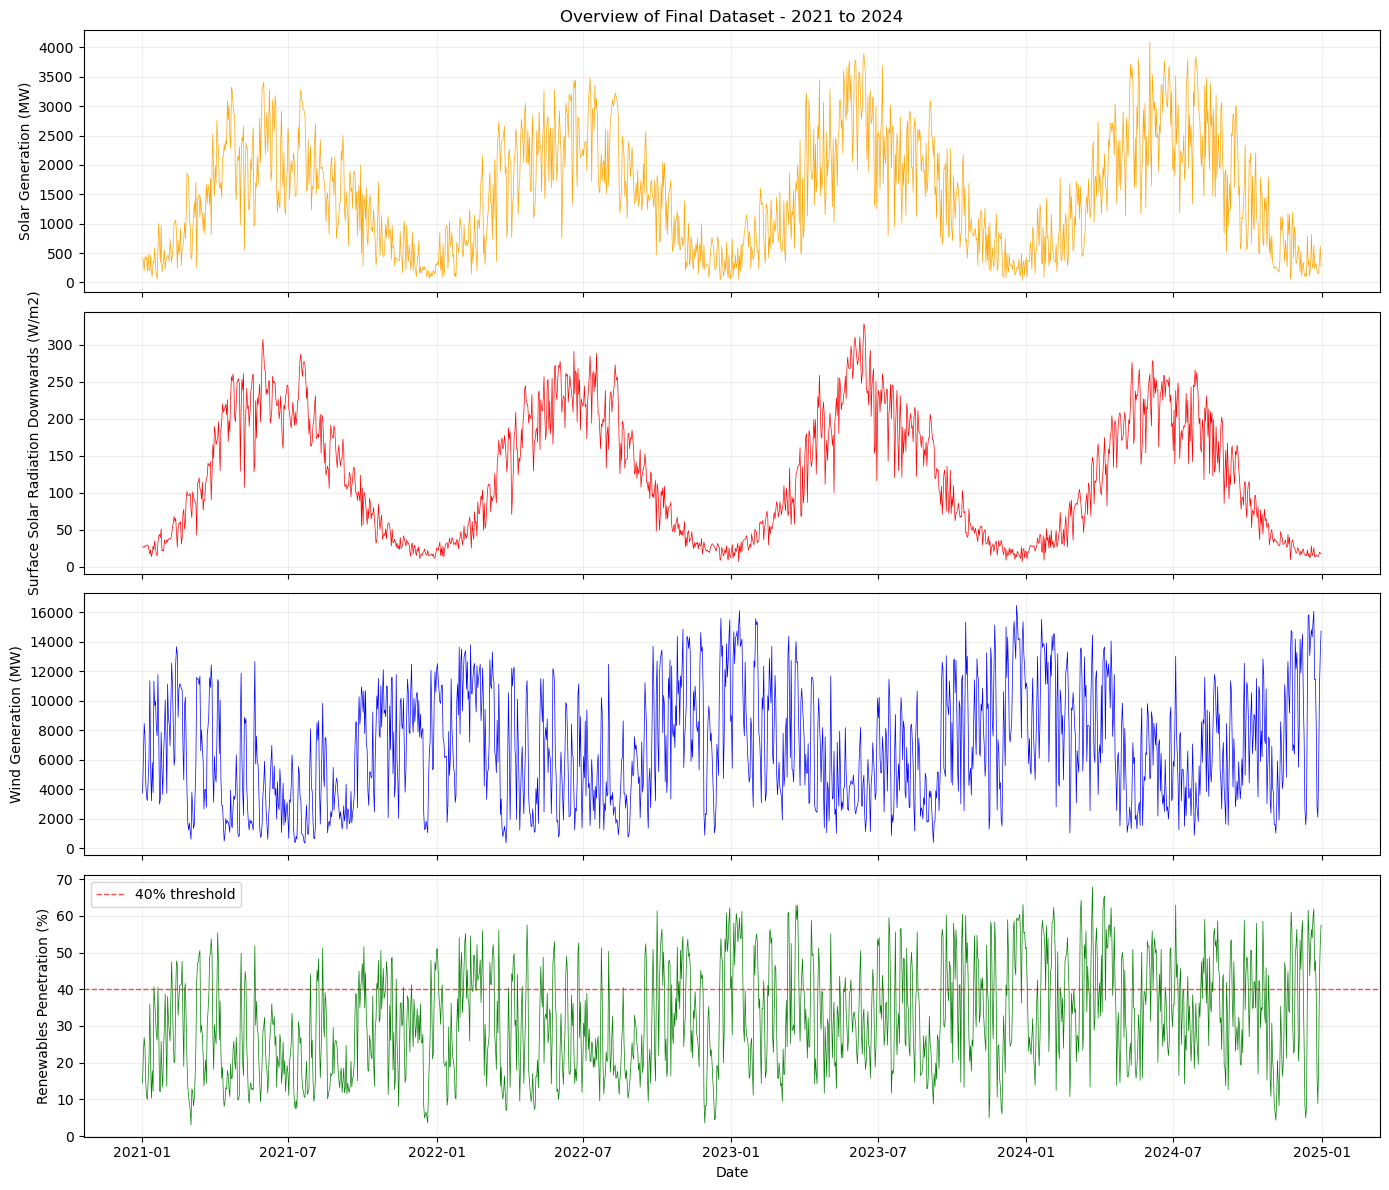

In [7]:
#Overview plot
daily = df_finalrel.resample('D').mean(numeric_only=True)

fig, axes = plt.subplots(4, 1, figsize=(14,12), sharex=True)

#Solar generation
axes[0].plot(daily.index, daily['generation_mw'], color='orange', linewidth=0.5)
axes[0].set_ylabel('Solar Generation (MW)')
axes[0].set_title('Overview of Final Dataset - 2021 to 2024')
axes[0].grid(True, alpha=0.2)

#Surface solar radiation downwards
axes[1].plot(daily.index, daily['ssrd'], color='red', linewidth=0.5)
axes[1].set_ylabel('Surface Solar Radiation Downwards (W/m2)')
axes[1].grid(True, alpha=0.2)

#Wind generation
axes[2].plot(daily.index, daily['wind_generation_mw'], color='blue', linewidth=0.5)
axes[2].set_ylabel('Wind Generation (MW)')
axes[2].grid(True, alpha=0.2)

#Renewable penetration
axes[3].plot(daily.index, daily['renewables_pct'], color='green', linewidth=0.5)
axes[3].axhline(y=40, color='red', linestyle='--', alpha=0.7,linewidth=1, label='40% threshold')
axes[3].set_ylabel('Renewables Penetration (%)')
axes[3].set_xlabel('Date')
axes[3].grid(True, alpha=0.2)
axes[3].legend(loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Plot Overview of Final Dataset.png"), dpi=150)
plt.show()


In [10]:
#Classify each hour into a penetration regime and count the samples in each
def classify_regime(pct):
    if pct < 25:
        return 'Low (<25%)'
    elif pct < 40:
        return 'Moderate (25-40%)'
    else:
        return 'High (> 40%)'
    
df_finalrel['regime'] = df_finalrel['renewables_pct'].apply(classify_regime)

regime_tiers = ['Low (<25%)', 'Moderate (25-40%)', 'High (> 40%)']
df_finalrel['regime'] = pd.Categorical(df_finalrel['regime'], categories=regime_tiers, ordered=True)

print(df_finalrel['regime'].value_counts().sort_index())

regime
Low (<25%)           13803
Moderate (25-40%)     9775
High (> 40%)         11462
Name: count, dtype: int64


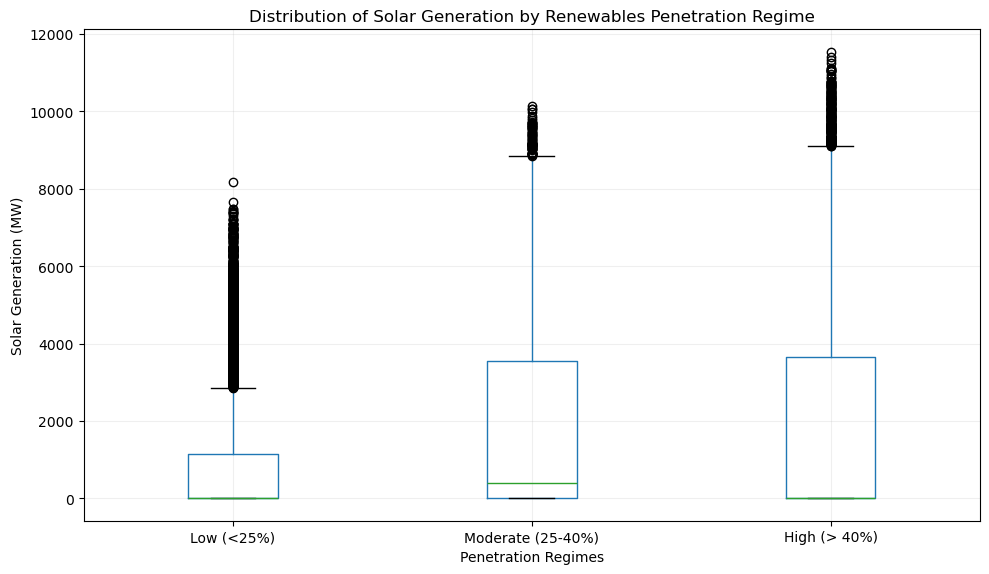

Summary statistics by regime:
                     count    mean     std  min  25%    50%     75%      max
regime                                                                      
Low (<25%)         13803.0   852.8  1471.1  0.0  0.0    0.1  1145.0   8166.8
Moderate (25-40%)   9775.0  1893.4  2479.6  0.0  0.0  393.5  3540.3  10147.1
High (> 40%)       11462.0  1949.9  2764.6  0.0  0.0   11.6  3642.3  11541.2


In [12]:
#Boxplot of solar generation by penetration regime
fig, ax = plt.subplots(figsize=(10,6))
df_finalrel.boxplot(column='generation_mw', by='regime', ax=ax)
ax.set_xlabel('Penetration Regimes')
ax.set_ylabel('Solar Generation (MW)')
ax.set_title('Distribution of Solar Generation by Renewables Penetration Regime')
plt.suptitle('')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Boxplot of Solar Generation by Penetration Regime.png"), dpi=150)
plt.show()

print("Summary statistics by regime:")
print(df_finalrel.groupby('regime', observed=True)['generation_mw'].describe().round(1))


Hours per penetration regime:
regime
Low (<25%)           13803
Moderate (25-40%)     9775
High (> 40%)         11462
Name: count, dtype: int64

Total percentage:
regime
Low (<25%)           39.4
Moderate (25-40%)    27.9
High (> 40%)         32.7
Name: count, dtype: float64


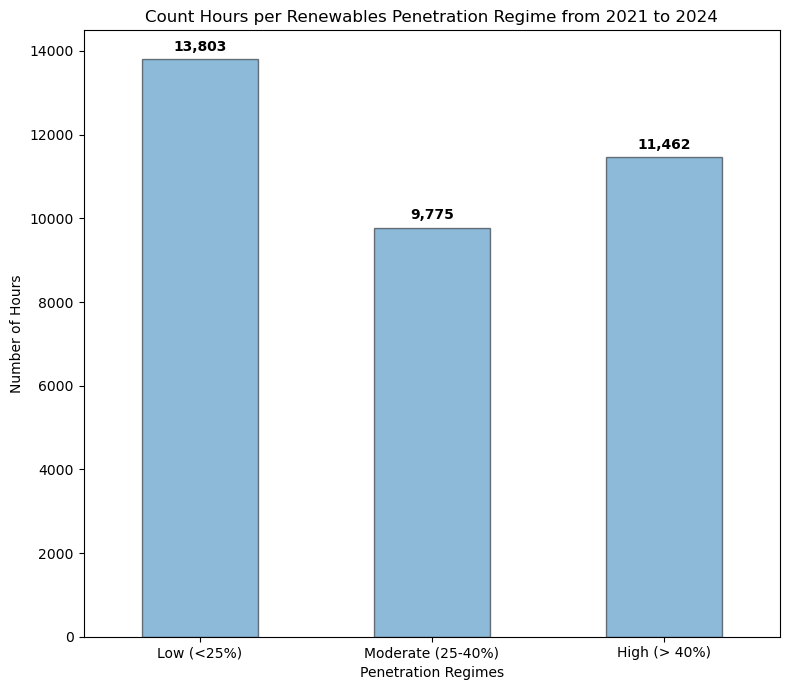

In [ ]:
#Plot regime counts hours per penetration regime
regime_count = df_finalrel['regime'].value_counts().sort_index()
print("Hours per penetration regime:")
print(regime_count)
print(f"\nTotal percentage:")
print((regime_count / len(df_finalrel) *100).round(1))

#Bar chart
fig, ax = plt.subplots(figsize=(8,7))
regime_count.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.5)
ax.set_xlabel('Penetration Regimes')
ax.set_ylabel('Number of Hours')
ax.set_title('Count Hours per Renewables Penetration Regime from 2021 to 2024')

for i, count in enumerate(regime_count):
    ax.text(i, count + 200, f"{count:,}", ha='center', fontweight='bold')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Count Hours per Penetration Regime.png"))
plt.show()

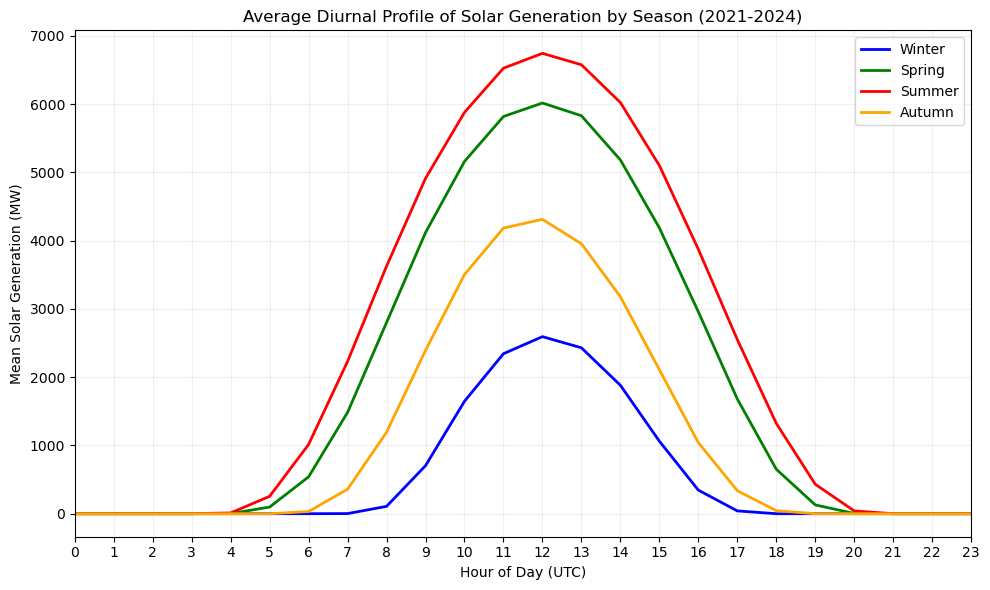

In [14]:
#Plot diurnal profile by season (2021-2024)
def map_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'
    
df_finalrel['season'] = df_finalrel.index.month.map(map_season)

season_sequence = ['Winter', 'Spring', 'Summer', 'Autumn']
season_palette = {'Winter': 'blue', 'Spring': 'green', 'Summer': 'red', 'Autumn': 'orange'}

fig, ax = plt.subplots(figsize=(10,6))

for season in season_sequence:
    mask = df_finalrel['season'] == season
    hourly_mean = df_finalrel[mask].groupby(df_finalrel[mask].index.hour)['generation_mw'].mean()
    ax.plot(hourly_mean.index, hourly_mean.values, label=season, color=season_palette[season], linewidth=2)

ax.set_xlabel('Hour of Day (UTC)')
ax.set_ylabel('Mean Solar Generation (MW)')
ax.set_title('Average Diurnal Profile of Solar Generation by Season (2021-2024)')
ax.legend()
ax.set_xlim(0, 23)
ax.set_xticks(range(0, 24))
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Diurnal Profile of Solar Generation by Season (2021-2024).png"), dpi=150)
plt.show()

#Dropping season column. Only needed for this plot
df_finalrel = df_finalrel.drop(columns=['season'])

Capacity growth: 13,503 to 19,126 MWp (41.6% increase)


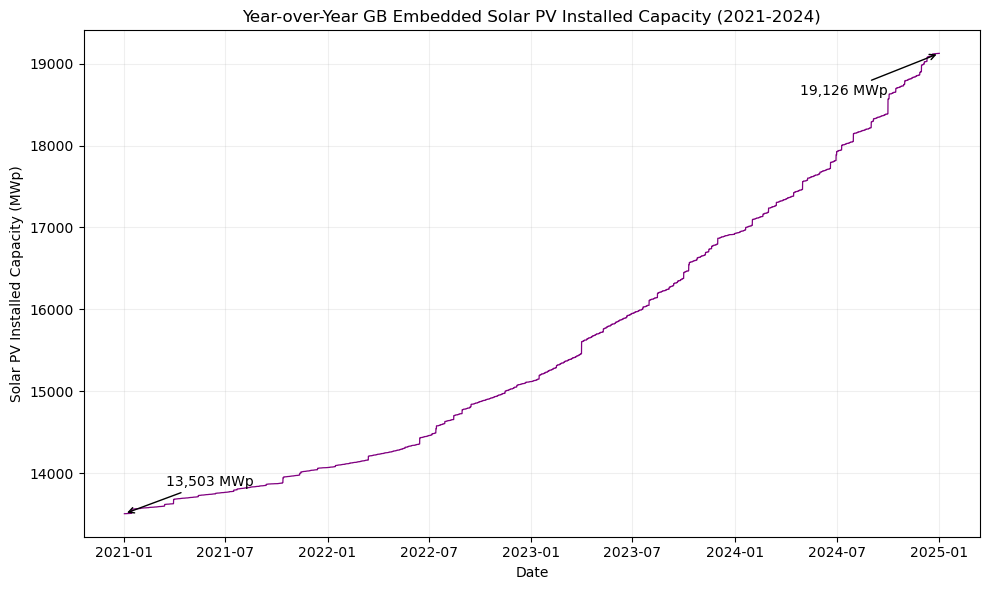

In [15]:
#Plot year-over-year solar PV capacity growth
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(df_finalrel.index, df_finalrel['capacity_mwp'], color='purple', linewidth=0.9)
ax.set_xlabel('Date')
ax.set_ylabel('Solar PV Installed Capacity (MWp)')
ax.set_title('Year-over-Year GB Embedded Solar PV Installed Capacity (2021-2024)')
ax.grid(True, alpha=0.2)

capacity_start = df_finalrel['capacity_mwp'].iloc[0]
capacity_end = df_finalrel['capacity_mwp'].iloc[-1]
growth_pct = ((capacity_end - capacity_start) / capacity_start) * 100
ax.annotate(f'{capacity_start:,.0f} MWp', xy=(df_finalrel.index[0], capacity_start), xytext=(30,20), textcoords='offset points', arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)
ax.annotate(f'{capacity_end:,.0f} MWp', xy=(df_finalrel.index[-1], capacity_end), xytext=(-100,-30), textcoords='offset points', arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)

print(f"Capacity growth: {capacity_start:,.0f} to {capacity_end:,.0f} MWp ({growth_pct:.1f}% increase)")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Year-over-Year Solar PV Installed Capacity (2021-2024).png"), dpi=150)
plt.show()

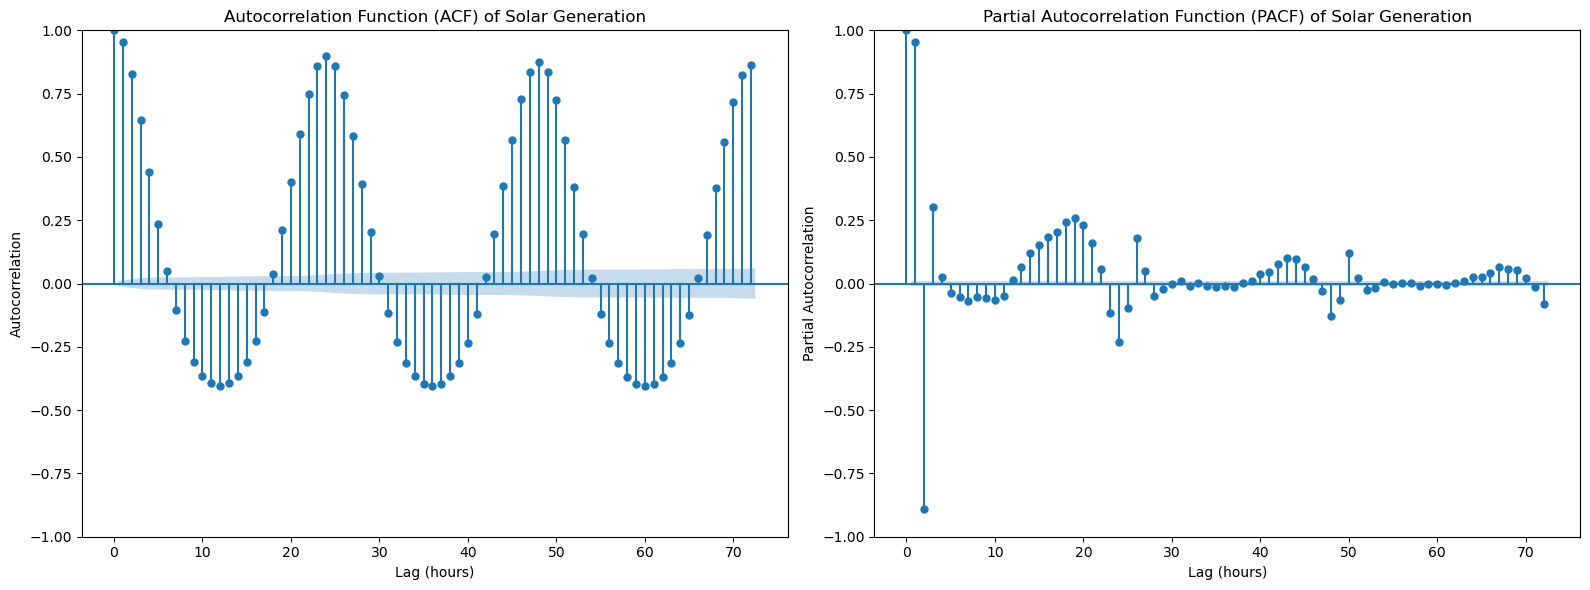

ACF value at lag 1: 0.9530
ACF value at lag 12: -0.4035
ACF value at lag 24: 0.8988
ACF value at lag 48: 0.8745
ACF value at lag 72: 0.8645

PACF value at lag 1: 0.9530
PACF value at lag 12: 0.0162
PACF value at lag 24: -0.2316
PACF value at lag 48: -0.1287
PACF value at lag 72: -0.0823


In [7]:
#ACF and PACF plots for solar generation
fig, axes = plt.subplots(1, 2, figsize=(16,6))

#ACF plot shows total correlation at each lag
plot_acf(df_finalrel['generation_mw'], lags=72, ax=axes[0], alpha=0.05)
axes[0].set_xlabel('Lag (hours)')
axes[0].set_ylabel('Autocorrelation')
axes[0].set_title('Autocorrelation Function (ACF) of Solar Generation', fontsize=12)

#PACF plot shows direct correlation only
plot_pacf(df_finalrel['generation_mw'], lags=72, ax=axes[1], alpha=0.05)
axes[1].set_xlabel('Lag (hours)')
axes[1].set_ylabel('Partial Autocorrelation')
axes[1].set_title('Partial Autocorrelation Function (PACF) of Solar Generation', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ACF and PACF of Solar Generation.png"), dpi=150, bbox_inches='tight')
plt.show()

from statsmodels.tsa.stattools import acf, pacf
acf_values = acf(df_finalrel['generation_mw'], nlags=72)
pacf_values = pacf(df_finalrel['generation_mw'], nlags=72)

print(f"ACF value at lag 1: {acf_values[1]:.4f}")
print(f"ACF value at lag 12: {acf_values[12]:.4f}")
print(f"ACF value at lag 24: {acf_values[24]:.4f}")
print(f"ACF value at lag 48: {acf_values[48]:.4f}")
print(f"ACF value at lag 72: {acf_values[72]:.4f}")
print(f"\nPACF value at lag 1: {pacf_values[1]:.4f}")
print(f"PACF value at lag 12: {pacf_values[12]:.4f}")
print(f"PACF value at lag 24: {pacf_values[24]:.4f}")
print(f"PACF value at lag 48: {pacf_values[48]:.4f}")
print(f"PACF value at lag 72: {pacf_values[72]:.4f}")


In [10]:
#ADF and KPSS stationarity tests

#ADF test
#Null: unit root exists (non-stationary)
#Reject (p < 0.05) = stationary
adf_result = adfuller(df_finalrel['generation_mw'], autolag='AIC')
print("ADF Test Results")
print(f"ADF Test Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.6f}")
print(f"Lags used: {adf_result[2]}")
print(f"Observations: {adf_result[3]}")
print(f"Critical values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")
print(f"\nConclusion: {'REJECT null hypothesis (stationary)' if adf_result[1] < 0.05 else 'FAIL TO REJECT null hypothesis (non-stationary)'}")

#KPSS test (level stationarity - tests for constant mean)
#Null: stationary
#Reject (p < 0.05) = non-stationary
print("\nKPSS Test Results (level stationarity, regression='c'):")
kpss_c_stat, kpss_c_p, kpss_c_lags, kpss_c_crit = kpss(df_finalrel['generation_mw'], regression='c', nlags='auto')
print(f"KPSS Test Statistic: {kpss_c_stat:.4f}")
print(f"p-value: {kpss_c_p:.4f}")
print(f"Lags used: {kpss_c_lags}")
print(f"Critical values:")
for key, value in kpss_c_crit.items():
    print(f"{key}: {value:.4f}")
print(f"\nConclusion: {'REJECT null hypothesis (non-stationary)' if kpss_c_p < 0.05 else 'FAIL TO REJECT null hypothesis (stationary)'}")

#KPSS test (level stationarity - tests after removing linear trend)
#Null: data is stationary around trend
#Reject = non-stationarity even after detrending
print("\nKPSS Test Results (trend stationarity, regression='ct'):")
kpss_ct_stat, kpss_ct_p, kpss_ct_lags, kpss_ct_crit = kpss(df_finalrel['generation_mw'], regression='ct', nlags='auto')
print(f"KPSS Test Statistic: {kpss_ct_stat:.4f}")
print(f"p-value: {kpss_ct_p:.4f}")
print(f"Lags used: {kpss_ct_lags}")
print(f"Critical values:")
for key, value in kpss_ct_crit.items():
    print(f"{key}: {value:.4f}")
print(f"\nConclusion: {'REJECT null hypothesis (non-stationary even after detrending)' if kpss_ct_p < 0.05 else 'FAIL TO REJECT null hypothesis (stationary around trend)'}")

#Summary of stationarity tests
print("\nSummary of Stationarity Tests for generation_mw:")
adf_stationary = adf_result[1] < 0.05
kpss_c_stationary = kpss_c_p >= 0.05
kpss_ct_stationary = kpss_ct_p >= 0.05
print(f"ADF Test: {'Stationary' if adf_stationary else 'Non-Stationary'} (p={adf_result[1]:.6f})")
print(f"KPSS Test (Level): {'Stationary' if kpss_c_stationary else 'Non-Stationary'} (p={kpss_c_p:.6f})")
print(f"KPSS Test (Trend): {'Stationary' if kpss_ct_stationary else 'Non-Stationary'} (p={kpss_ct_p:.6f})")


ADF Test Results
ADF Test Statistic: -8.8450
p-value: 0.000000
Lags used: 52
Observations: 34987
Critical values:
1%: -3.4305
5%: -2.8616
10%: -2.5668

Conclusion: REJECT null hypothesis (stationary)

KPSS Test Results (level stationarity, regression='c'):
KPSS Test Statistic: 2.3745
p-value: 0.0100
Lags used: 21
Critical values:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390

Conclusion: REJECT null hypothesis (non-stationary)

KPSS Test Results (trend stationarity, regression='ct'):
KPSS Test Statistic: 1.7644
p-value: 0.0100
Lags used: 22
Critical values:
10%: 0.1190
5%: 0.1460
2.5%: 0.1760
1%: 0.2160

Conclusion: REJECT null hypothesis (non-stationary even after detrending)

Summary of Stationarity Tests for generation_mw:
ADF Test: Stationary (p=0.000000)
KPSS Test (Level): Non-Stationary (p=0.010000)
KPSS Test (Trend): Non-Stationary (p=0.010000)


C:\Users\emran\AppData\Local\Temp\ipykernel_50860\1704037413.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_c_stat, kpss_c_p, kpss_c_lags, kpss_c_crit = kpss(df_finalrel['generation_mw'], regression='c', nlags='auto')
C:\Users\emran\AppData\Local\Temp\ipykernel_50860\1704037413.py:34: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_ct_stat, kpss_ct_p, kpss_ct_lags, kpss_ct_crit = kpss(df_finalrel['generation_mw'], regression='ct', nlags='auto')


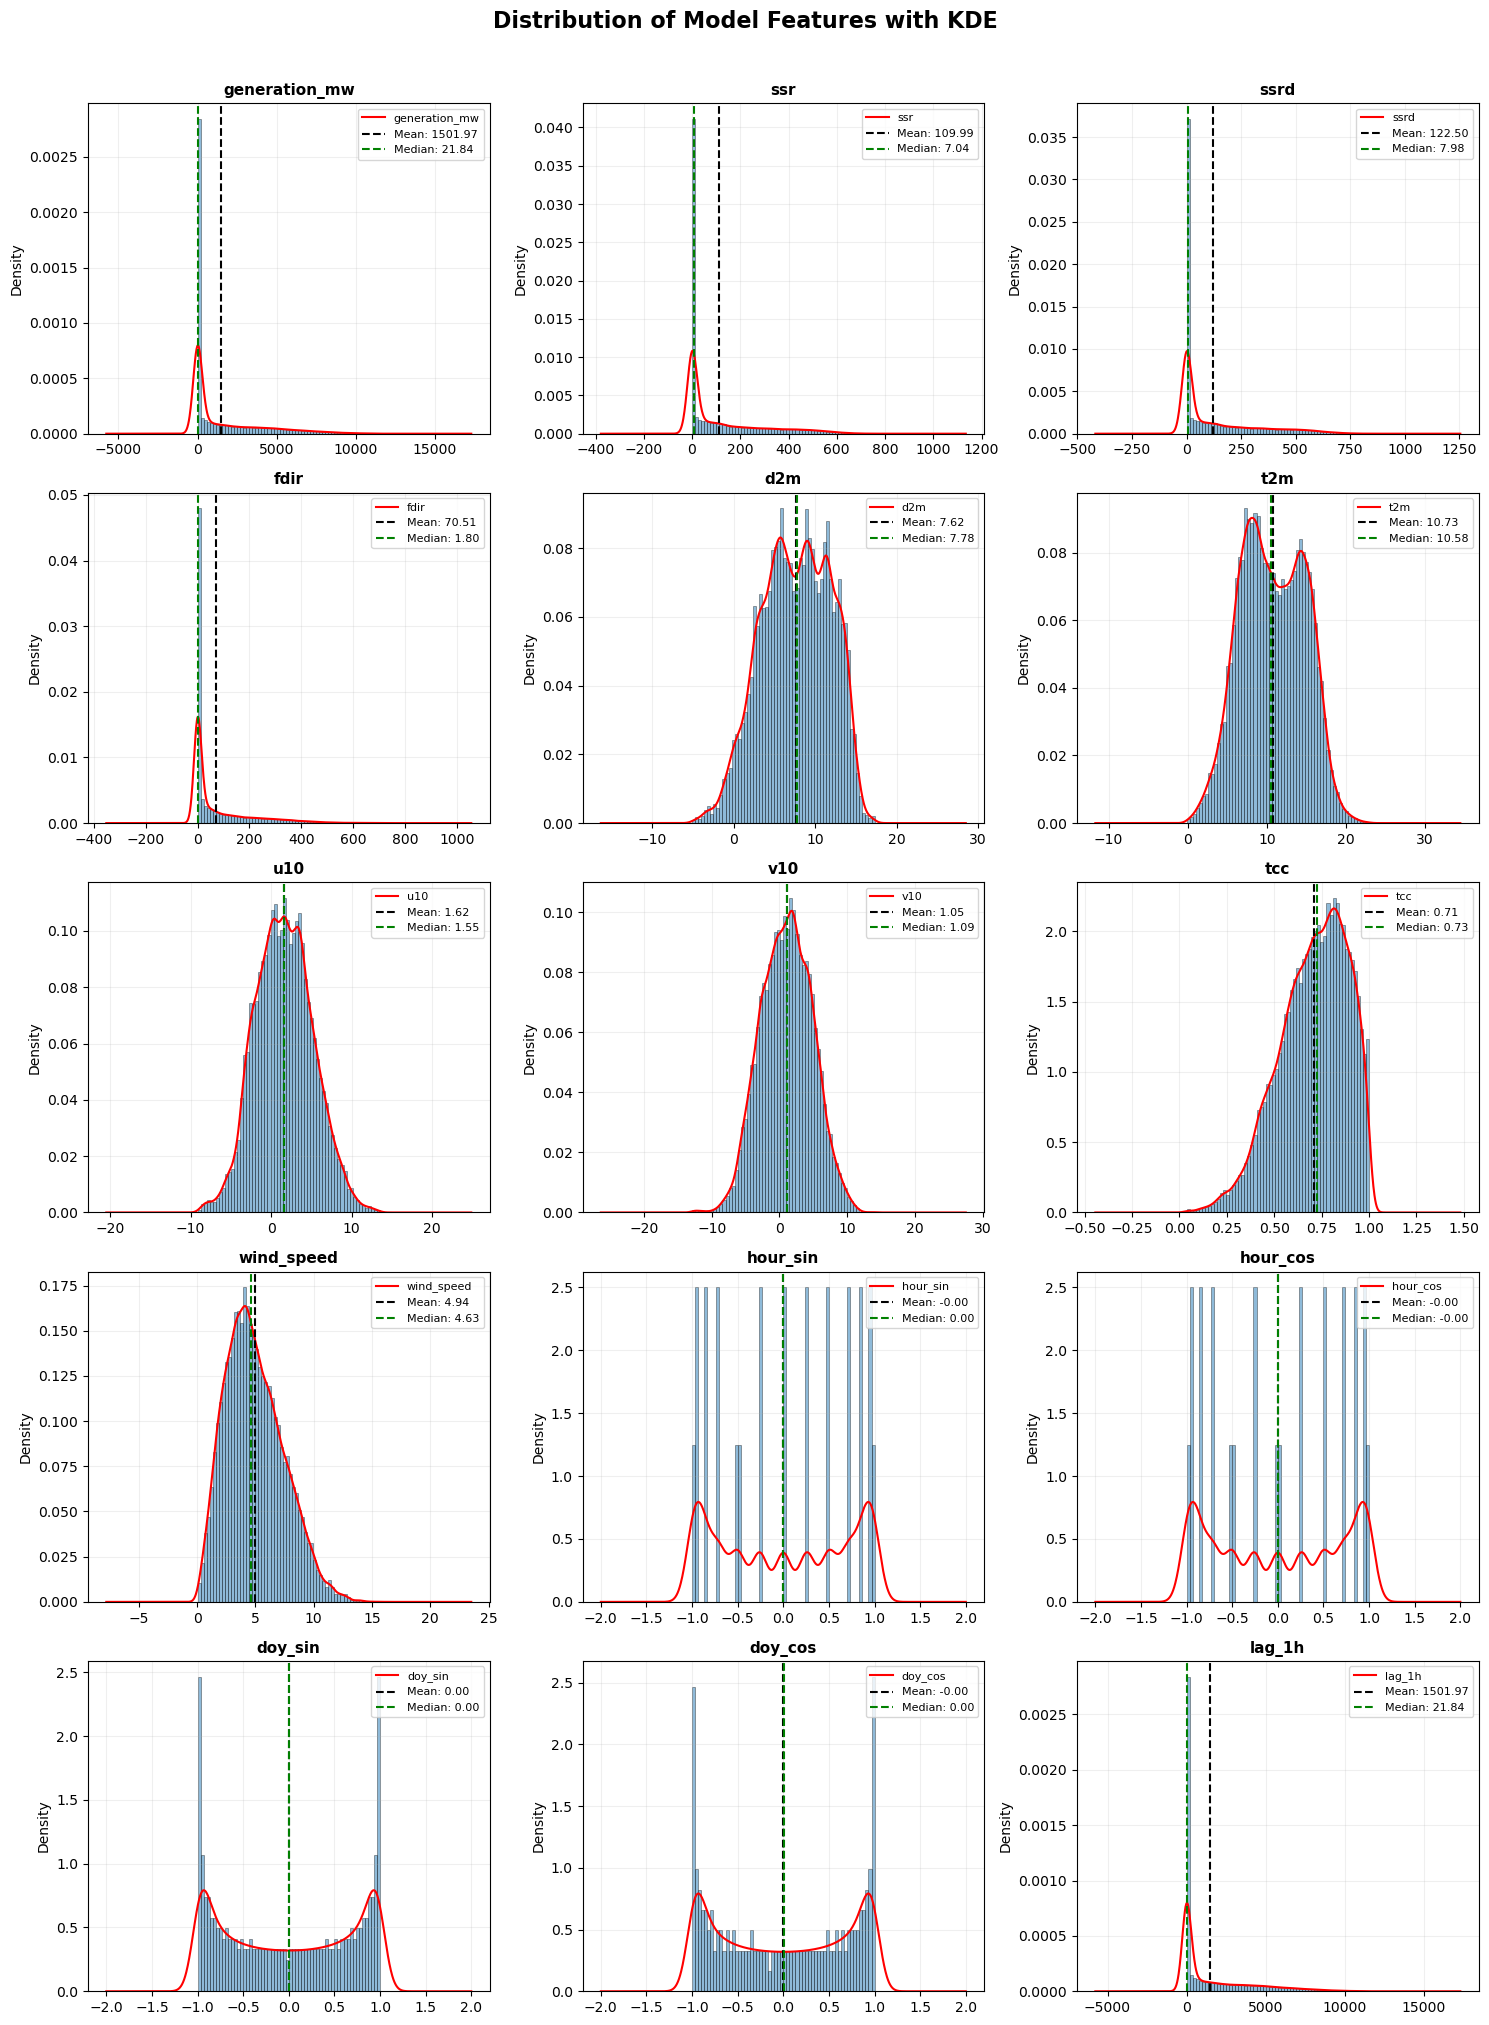

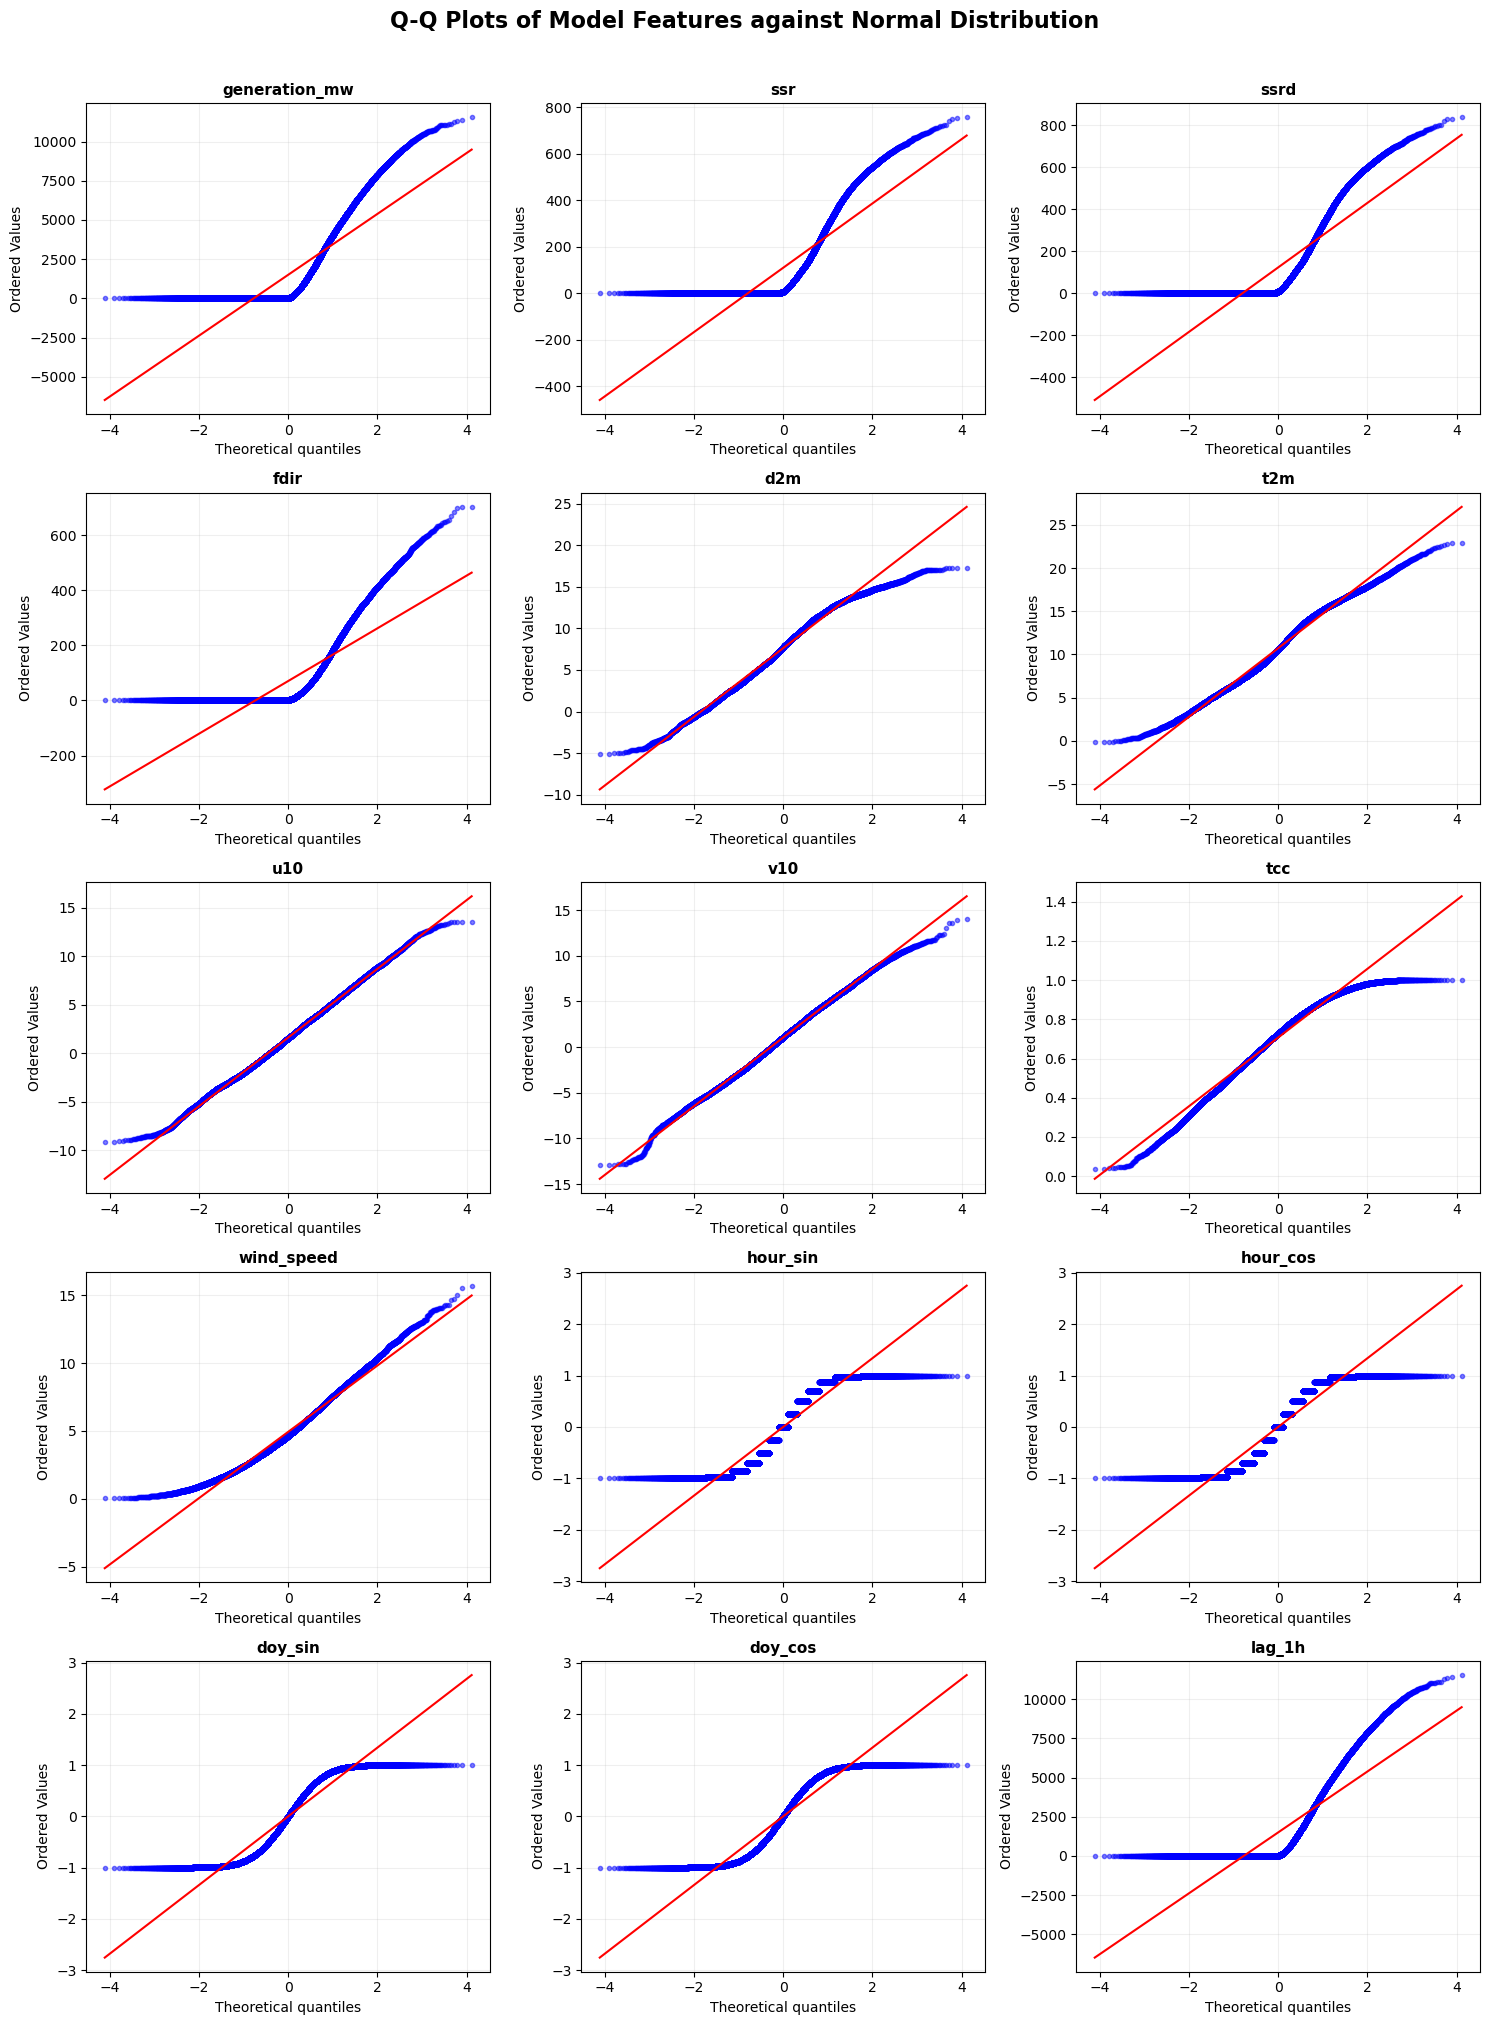

Feature                Skewness   Kurtosis         Mean       Median
generation_mw            1.5949     1.6895   1501.9669      21.8422
ssr                      1.4758     1.1032    109.9879       7.0427
ssrd                     1.4589     1.0496    122.5018       7.9810
fdir                     1.8947     3.0300     70.5071       1.7955
d2m                     -0.2017    -0.6744      7.6220       7.7800
t2m                      0.0059    -0.7638     10.7340      10.5801
u10                      0.1068    -0.1516      1.6188       1.5513
v10                     -0.0251    -0.2816      1.0451       1.0894
tcc                     -0.5606    -0.1572      0.7070       0.7276
wind_speed               0.5173    -0.1221      4.9362       4.6309
hour_sin                 0.0000    -1.5000     -0.0000       0.0000
hour_cos                -0.0000    -1.5000     -0.0000      -0.0000
doy_sin                  0.0000    -1.5000      0.0000       0.0000
doy_cos                 -0.0000    -1.5000     

In [13]:
#Distribution and Q-Q diagnostics for all model features
plot_features = [
    'generation_mw', 'ssr', 'ssrd', 'fdir', 'd2m', 't2m', 'u10', 'v10', 'tcc',
    'wind_speed', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'lag_1h'
]

#Distribution histograms with KDE
fig, axes = plt.subplots(5,3, figsize=(15, 20))
axes = axes.flatten()

for index, feature in enumerate(plot_features):
    ax=axes[index]
    data = df_finalrel[feature].dropna()
    ax.hist(data, bins=60, edgecolor='black', alpha=0.5, linewidth=0.5, density=True)
    data.plot.kde(ax=ax, color='red', linewidth=1.5)
    ax.axvline(x=data.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.2f}')
    ax.axvline(x=data.median(), color='green', linestyle='--', linewidth=1.5, label=f'Median: {data.median():.2f}')
    ax.set_title(feature, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylabel('Density')
    ax.grid(True, alpha=0.2)

fig.suptitle('Distribution of Model Features with KDE', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Distribution of Model Features with KDE.png"), dpi=150, bbox_inches='tight')
plt.show()

#Q-Q plots against normal distributions
fig, axes = plt.subplots(5,3, figsize=(15, 20))
axes = axes.flatten()

for index, feature in enumerate(plot_features):
    ax=axes[index]
    data = df_finalrel[feature].dropna()
    probplot(data, dist="norm", plot=ax)
    ax.set_title(feature, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.2)
    ax.get_lines()[0].set_markersize(3)
    ax.get_lines()[0].set_alpha(0.5)

fig.suptitle('Q-Q Plots of Model Features against Normal Distribution', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Q-Q Plots of Model Features against Normal Distribution.png"), dpi=150, bbox_inches='tight')
plt.show()

#Skewness and kurtosis values
print(f"{'Feature':<20} {'Skewness':>10} {'Kurtosis':>10} {'Mean':>12} {'Median':>12}")
for feature in plot_features:
    data = df_finalrel[feature]
    print(f"{feature:<20} {data.skew():>10.4f} {data.kurtosis():>10.4f}"
          f"{data.mean():>12.4f} {data.median():>12.4f}")


C:\Users\emran\AppData\Local\Temp\ipykernel_30956\3677133999.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


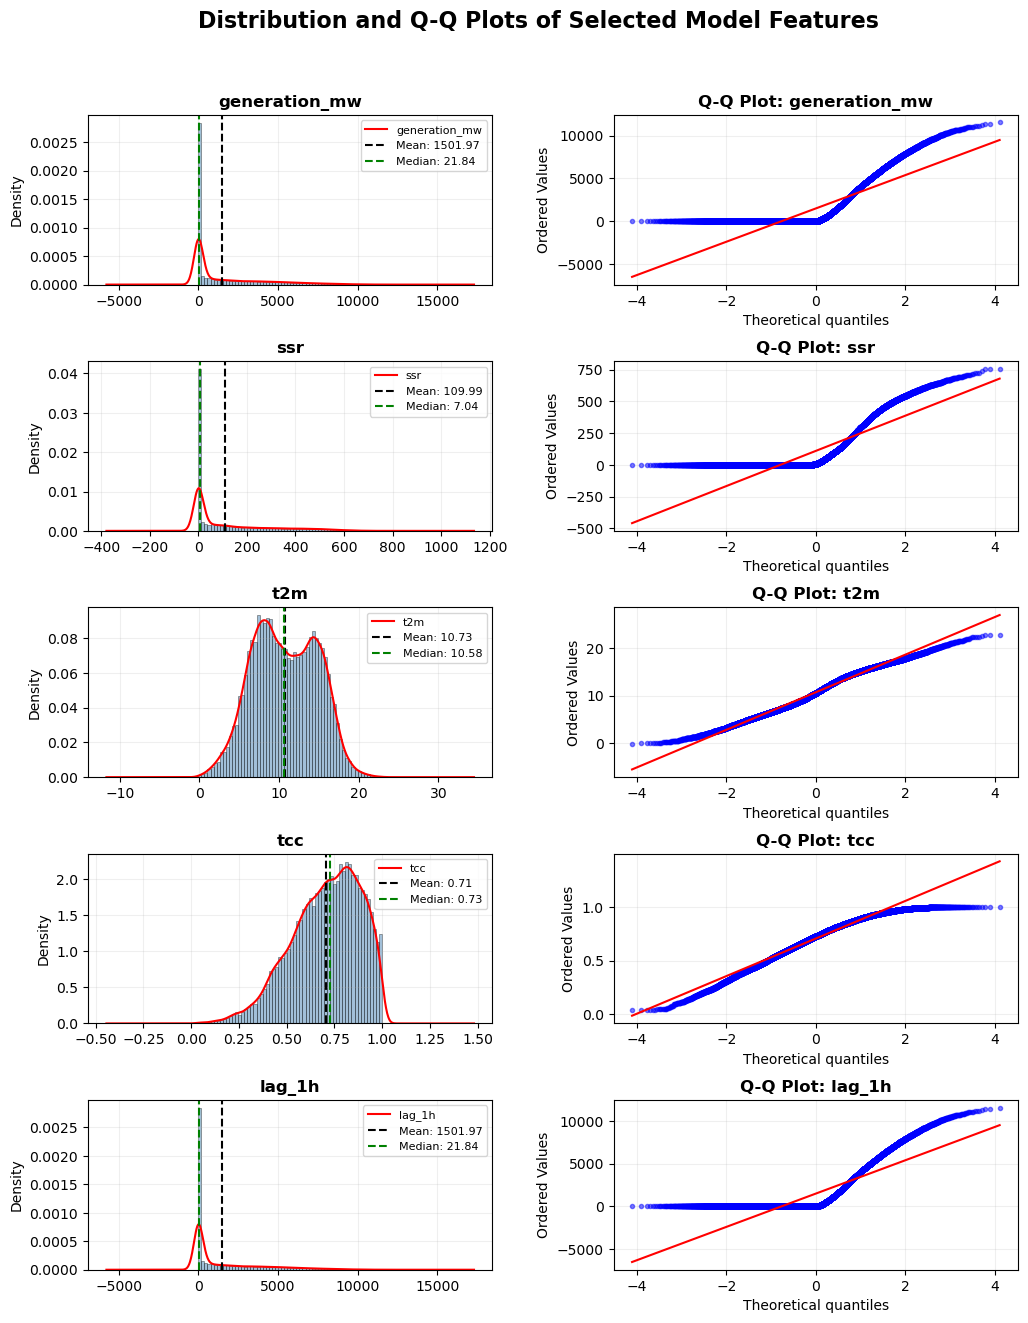

Feature                Skewness   Kurtosis         Mean       Median
generation_mw            1.5949     1.6895    1501.9669      21.8422
ssr                      1.4758     1.1032     109.9879       7.0427
t2m                      0.0059    -0.7638      10.7340      10.5801
tcc                     -0.5606    -0.1572       0.7070       0.7276
lag_1h                   1.5949     1.6895    1501.9669      21.8422


In [10]:
#Distribution and Q-Q diagnostics for selected model features
selected_features = [('generation_mw', 'Target variable - highly right skewed with zero-inflation bound'),
                     ('ssr', 'Primary radiation predictor'), 
                     ('t2m', '2-metre temperature - approximately Gaussian'),
                     ('tcc', 'Total cloud cover - bimodal distribution'),
                     ('lag_1h', 'Lag feature - shows autoregressive lag')]

#Distribution histograms with KDE
fig, axes = plt.subplots(nrows=len(selected_features), 
                         ncols=2,
                         figsize=(12,3 * len(selected_features)), 
                         gridspec_kw={'wspace': 0.3, 'hspace': 0.45})

for row_index, (feature, description) in enumerate(selected_features):
    ax_dist = axes[row_index, 0]
    ax_qq = axes[row_index, 1]
    data = df_finalrel[feature].dropna()
    ax_dist.hist(data, bins=60, edgecolor='black', alpha=0.5, linewidth=0.5, color='steelblue', density=True)
    data.plot.kde(ax=ax_dist, color='red', linewidth=1.5, label=feature)
    ax_dist.axvline(x=data.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.2f}')
    ax_dist.axvline(x=data.median(), color='green', linestyle='--', linewidth=1.5, label=f'Median: {data.median():.2f}')
    ax_dist.set_title(f'{feature}', fontsize=12, fontweight='bold')
    ax_dist.set_ylabel('Density', fontsize=10)
    ax_dist.legend(fontsize=8, loc='upper right')
    ax_dist.grid(True, alpha=0.2)

    #Q-Q plots against normal distributions
    probplot(data, dist='norm', plot=ax_qq)
    ax_qq.set_title(f'Q-Q Plot: {feature}', fontsize=12, fontweight='bold')
    ax_qq.grid(True, alpha=0.2)
    ax_qq.get_lines()[0].set_markersize(3)
    ax_qq.get_lines()[0].set_alpha(0.5)

fig.suptitle('Distribution and Q-Q Plots of Selected Model Features', fontsize=16, fontweight='bold', y=0.95)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Distribution and Q-Q Plots of Selected Model Features.png"), dpi=150, bbox_inches='tight')
plt.show()

#Summary statistics - Skewness and kurtosis values
print(f"{'Feature':<20} {'Skewness':>10} {'Kurtosis':>10} {'Mean':>12} {'Median':>12}")
for feature, _ in selected_features:
    data = df_finalrel[feature]
    print(f"{feature:<20} {data.skew():>10.4f} {data.kurtosis():>10.4f} "
          f"{data.mean():>12.4f} {data.median():>12.4f}")


In [15]:
#Outlier detection using Z-score and IQR methods
generation_data = df_finalrel['generation_mw']

#Z-score method
z_scores = np.abs(stats.zscore(generation_data))
z_outliers = z_scores > 3
z_outlier_count = z_outliers.sum()
z_outlier_pct = (z_outlier_count / len(generation_data)) * 100

print(f"\nZ-score method: {z_outlier_count} outliers detected ({z_outlier_pct:.2f}% of data)")
print(f"Mean: {generation_data.mean():.4f}")
print(f"Std: {generation_data.std():.4f}")
print(f"z-score threshold: +/-{3 * generation_data.std():.4f} MW from mean")
print(f"Upper bound: {generation_data.mean() + 3 * generation_data.std():.4f} MW")
print(f"Lower bound: {generation_data.mean() - 3 * generation_data.std():.4f} MW")
print(f"Outliers detected: {z_outlier_count} ({z_outlier_pct:.2f}% of data)")
print(f"Min outlier value: {generation_data[z_outliers].min():.4f} MW")
print(f"Max outlier value: {generation_data[z_outliers].max():.4f} MW")


Z-score method: 512 outliers detected (1.46% of data)
Mean: 1501.9669
Std: 2311.2541
z-score threshold: +/-6933.7622 MW from mean
Upper bound: 8435.7291 MW
Lower bound: -5431.7953 MW
Outliers detected: 512 (1.46% of data)
Min outlier value: 8440.2900 MW
Max outlier value: 11541.2500 MW


In [16]:
#IQR method
Q1 = generation_data.quantile(0.25)
Q3 = generation_data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
iqr_outliers = (generation_data < lower_bound) | (generation_data > upper_bound)
iqr_outlier_count = iqr_outliers.sum()
iqr_outlier_pct = (iqr_outlier_count / len(generation_data)) * 100

print(f"\nIQR method: {iqr_outlier_count} outliers detected ({iqr_outlier_pct:.2f}% of data)")
print(f"Q1 (25th percentile): {Q1:.4f} MW")
print(f"Q3 (75th percentile): {Q3:.4f} MW")
print(f"IQR: {IQR:.4f} MW")
print(f"Lower bound: {lower_bound:.4f} MW (Q1 - 1.5 * IQR)")
print(f"Upper bound: {upper_bound:.4f} MW (Q3 + 1.5 * IQR)")
print(f"Outliers detected: {iqr_outlier_count} ({iqr_outlier_pct:.2f}% of data)")
print(f"Above upper fence: {(generation_data > upper_bound).sum()}")
print(f"Below lower fence: {(generation_data < lower_bound).sum()}")

#Find when the outliers occurred
iqr_outliers_hr = df_finalrel.loc[iqr_outliers].index.hour
print(f"\nIQR Outlier hour of day distribution (top 5 hours):")
hr_counts = iqr_outliers_hr.value_counts().sort_values(ascending=False)
for hr, count in hr_counts.head(5).items():
    print(f"Hour {hr:02d}: {count} outliers")


IQR method: 2337 outliers detected (6.67% of data)
Q1 (25th percentile): 0.0000 MW
Q3 (75th percentile): 2453.6512 MW
IQR: 2453.6512 MW
Lower bound: -3680.4769 MW (Q1 - 1.5 * IQR)
Upper bound: 6134.1281 MW (Q3 + 1.5 * IQR)
Outliers detected: 2337 (6.67% of data)
Above upper fence: 2337
Below lower fence: 0

IQR Outlier hour of day distribution (top 5 hours):
Hour 12: 478 outliers
Hour 11: 444 outliers
Hour 13: 444 outliers
Hour 10: 331 outliers
Hour 14: 320 outliers


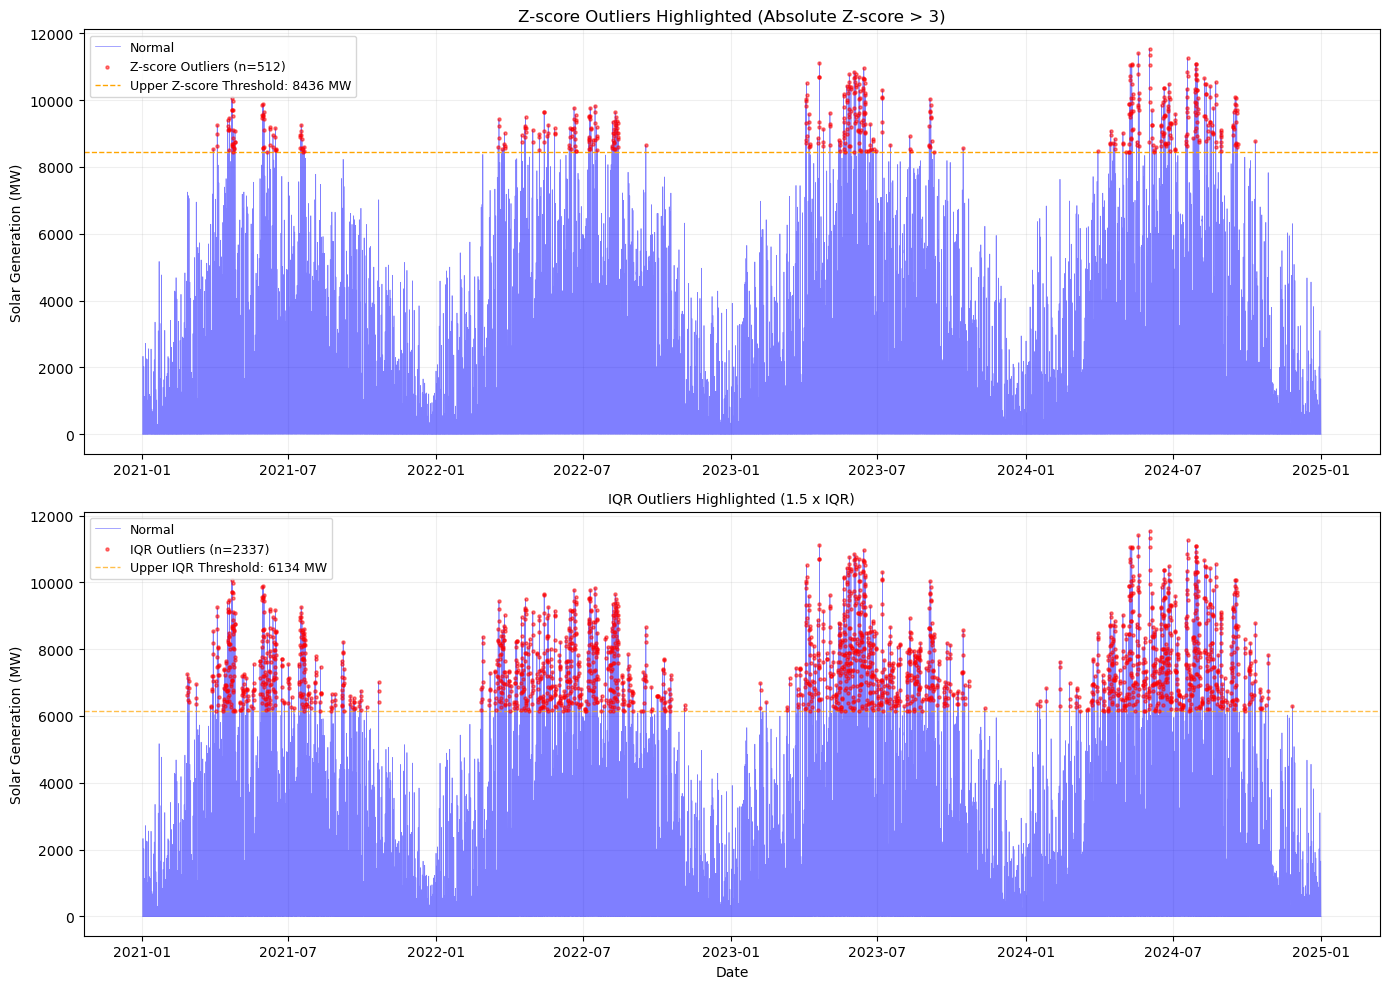

In [17]:
#Plots with outliers highlighted
fig, axes = plt.subplots(2,1, figsize=(14,10))

#z-score outliers
axes[0].plot(df_finalrel.index, generation_data, color='blue', linewidth=0.5, label='Normal', alpha=0.5)
axes[0].scatter(df_finalrel.index[z_outliers], generation_data[z_outliers], color='red', s=5, label=f'Z-score Outliers (n={z_outlier_count})', zorder=5, alpha=0.5)
axes[0].axhline(y=generation_data.mean() + 3 * generation_data.std(), color='orange', linestyle='--', linewidth=1, label=f'Upper Z-score Threshold: {generation_data.mean() + 3 * generation_data.std():.0f} MW')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.2)
axes[0].set_ylabel('Solar Generation (MW)')
axes[0].set_title('Z-score Outliers Highlighted (Absolute Z-score > 3)')

#IQR outliers
axes[1].plot(df_finalrel.index, generation_data, color='blue', linewidth=0.5, label='Normal', alpha=0.5)
axes[1].scatter(df_finalrel.index[iqr_outliers], generation_data[iqr_outliers], color='red', s=5, label=f'IQR Outliers (n={iqr_outlier_count})', zorder=5, alpha=0.5)
axes[1].axhline(y=upper_bound, color='orange', linestyle='--', linewidth=1, label=f'Upper IQR Threshold: {upper_bound:.0f} MW', alpha=0.7)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.2)
axes[1].set_ylabel('Solar Generation (MW)')
axes[1].set_xlabel('Date')
axes[1].set_title('IQR Outliers Highlighted (1.5 x IQR)', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Z-score and IQR Outlier Detection.png"), dpi=150, bbox_inches='tight')
plt.show()

In [20]:
#Outlier treatment methods and statistical comparison
#Median replacement
median_val = generation_data.median()
gen_median_replaced = generation_data.copy()
gen_median_replaced[iqr_outliers] = median_val

#Winsorisation at 95th percentile - cap values above 95th percentile 
percentile95 = generation_data.quantile(0.95)
gen_winsorised = generation_data.copy()
gen_winsorised[generation_data > percentile95] = percentile95

#Comparing summary statistics
df_treatments = pd.DataFrame({
    'Original': generation_data,
    'Median Replaced': gen_median_replaced,
    'Winsorised (95th)': gen_winsorised
})

stats_comparison = df_treatments.describe().loc[['mean', '50%', 'std', 'min', 'max']]
stats_comparison.loc['Skewness'] = df_treatments.skew()
stats_comparison.loc['Kurtosis'] = df_treatments.kurt()
stats_comparison.index = ['Mean (MW)', 'Median(MW)', 'Std (MW)', 'Min (MW)', 'Max (MW)', 'Skewness', 'Kurtosis']

print(f"Summary Statistics: Before and After Outlier Treatment")
print(stats_comparison.round(2).to_string())

print(f"\n{'-' * 50}")
print("Analysis of Signal Loss")
print(f"{'-' * 50}")
print(f"Median replacement:")
print(f" Values changed: {iqr_outlier_count} ({iqr_outlier_pct:.2f}%)")
print(f" Mean reduction: {generation_data.mean() - gen_median_replaced.mean():.2f} MW"
      f"({(generation_data.mean() - gen_median_replaced.mean()) / generation_data.mean() * 100:.1f}%)")
print(f" Max value: Reduced from {generation_data.max():.2f} to {gen_median_replaced.max():.2f} MW")

print(f"\nWinsorisation of 95th percentile:")
winsor_count = (generation_data > percentile95).sum()
print(f" Values capped: {winsor_count} ({winsor_count / len(generation_data) * 100:.2f}%)")
print(f" Cap value (P95): {percentile95:.2f} MW")
print(f" Mean reduction: {generation_data.mean() - gen_winsorised.mean():.2f} MW"
      f"({(generation_data.mean() - gen_winsorised.mean()) / generation_data.mean() *100:.1f}%)")
print(f" Max value: Reduced from {generation_data.max():.2f} to {gen_winsorised.max():.2f} MW")

Summary Statistics: Before and After Outlier Treatment
            Original  Median Replaced  Winsorised (95th)
Mean (MW)    1501.97           996.64            1434.98
Median(MW)     21.84            21.81              21.84
Std (MW)     2311.25          1633.35            2122.10
Min (MW)        0.00             0.00               0.00
Max (MW)    11541.25          6132.78            6660.68
Skewness        1.59             1.58               1.32
Kurtosis        1.69             1.24               0.37

--------------------------------------------------
Analysis of Signal Loss
--------------------------------------------------
Median replacement:
 Values changed: 2337 (6.67%)
 Mean reduction: 505.33 MW(33.6%)
 Max value: Reduced from 11541.25 to 6132.78 MW

Winsorisation of 95th percentile:
 Values capped: 1752 (5.00%)
 Cap value (P95): 6660.68 MW
 Mean reduction: 66.99 MW(4.5%)
 Max value: Reduced from 11541.25 to 6660.68 MW


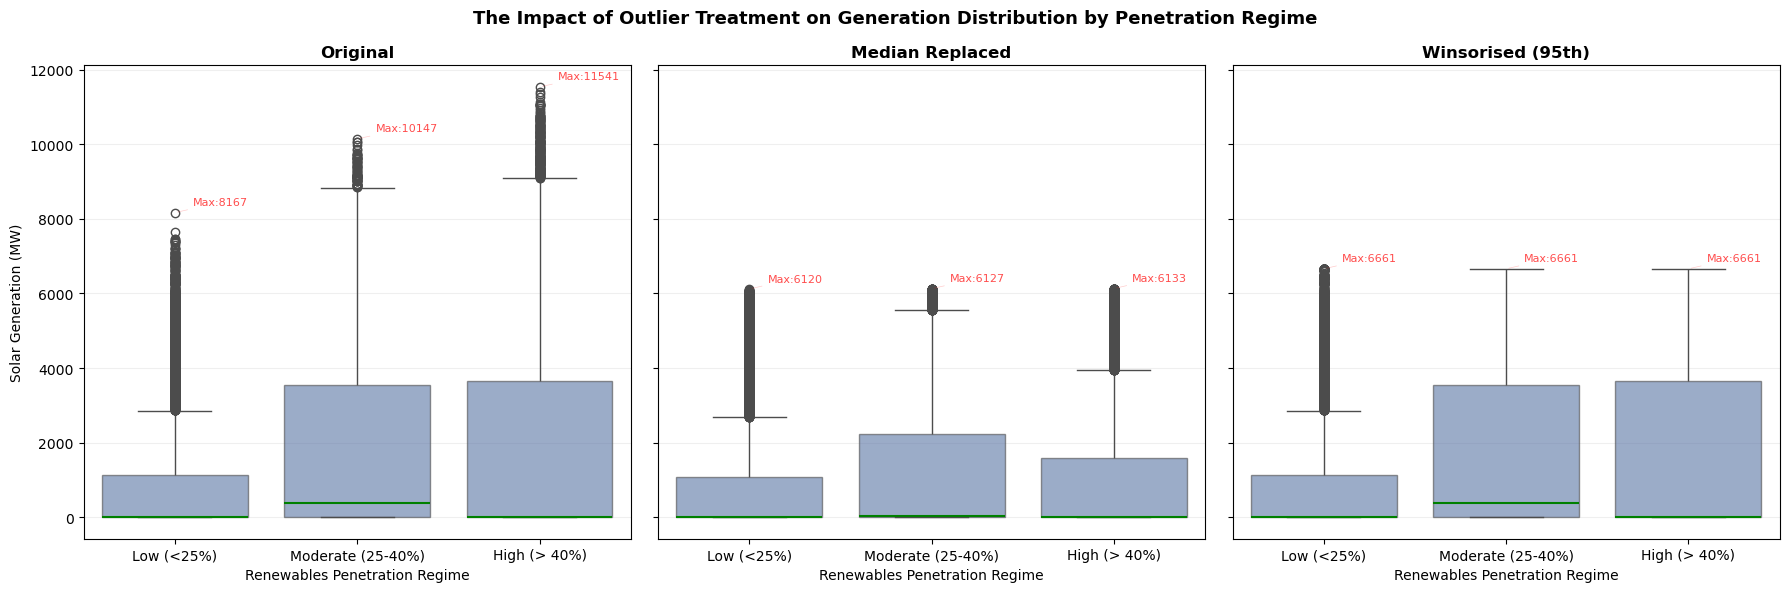


Regime-Level Impact of Outlier Treatment (Max Values):
                   Original  Median Replaced  Winsorised (95th)
regime                                                         
Low (<25%)          8166.80          6119.82            6660.68
Moderate (25-40%)  10147.10          6127.48            6660.68
High (> 40%)       11541.25          6132.78            6660.68


In [31]:
#Plot before and after outlier treatments
regime_tiers = ['Low (<25%)', 'Moderate (25-40%)', 'High (> 40%)']
treatments = ['Original', 'Median Replaced', 'Winsorised (95th)']
colors = ['#4C72B0', '#DD8452', '#55A868']

df_boxplot = pd.DataFrame({
    'regime': df_finalrel['regime'],
    'Original': generation_data,
    'Median Replaced': gen_median_replaced,
    'Winsorised (95th)': gen_winsorised
})

fig, axes = plt.subplots(1, 3, figsize=(18,6), sharey=True)

for ax, treatment, color in zip(axes, treatments, colors):
    sns.boxplot(data=df_boxplot, x='regime', y=treatment, order=regime_tiers, color='#4c72B0', boxprops=dict(alpha=0.6), medianprops=dict(color='green', linewidth=1.5), ax=ax)

    ax.set_xlabel('Renewables Penetration Regime')
    ax.set_ylabel('')
    ax.grid(True, alpha=0.2, axis='y')
    ax.set_title(treatment, fontsize=12, fontweight='bold')

    for index, regime in enumerate(regime_tiers):
        regime_max = df_boxplot.loc[df_boxplot['regime'] == regime, treatment].max()
        ax.annotate(f'Max:{regime_max:.0f}', xy=(index, regime_max), xytext=(index + 0.10, regime_max + 200), fontsize=8,
                    color='red', alpha=0.7, arrowprops=dict(arrowstyle='-', color='red', alpha=0.2, lw=0.5))
        
axes[0].set_ylabel('Solar Generation (MW)')
fig.suptitle('The Impact of Outlier Treatment on Generation Distribution by Penetration Regime', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Boxplots of Before and After Outlier Treatment.png"), dpi=150, bbox_inches='tight')
plt.show()

#Regime-level impact from outlier treatment
print(f"\nRegime-Level Impact of Outlier Treatment (Max Values):")
max_summary = df_boxplot.groupby('regime')[treatments].max().reindex(regime_tiers)
print(max_summary.round(2).to_string())

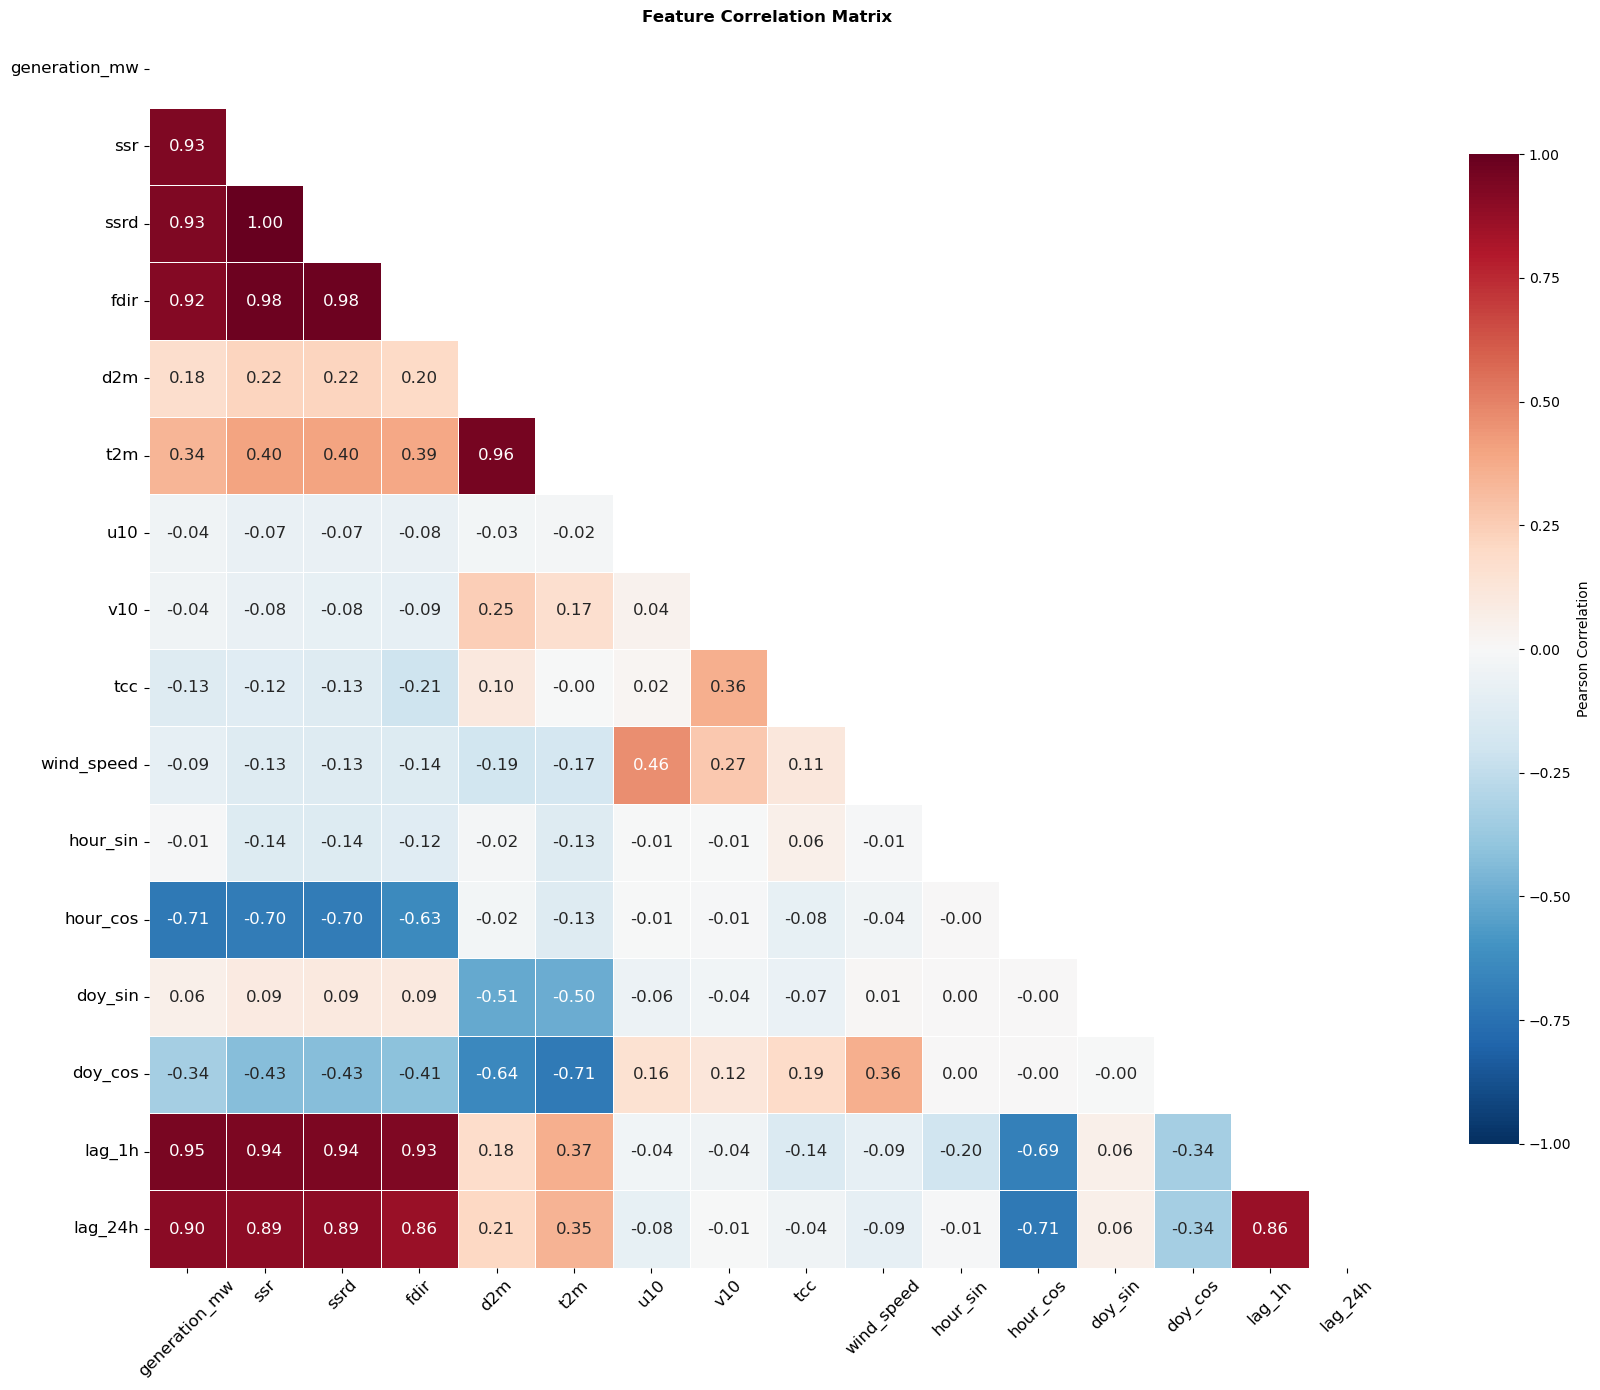


Correlations strongest with generation_mw (sorted by absolute r):
 lag_1h          +0.953
 ssrd            +0.932
 ssr             +0.931
 fdir            +0.921
 lag_24h         +0.899
 hour_cos        -0.713
 t2m             +0.338
 doy_cos         -0.337
 d2m             +0.179
 tcc             -0.132
 wind_speed      -0.093
 doy_sin         +0.062
 v10             -0.044
 u10             -0.040
 hour_sin        -0.012


In [38]:
#Plot improved correlation heatmap
corr_feature = ['generation_mw', 'ssr', 'ssrd', 'fdir', 'd2m', 't2m', 'u10', 'v10', 'tcc',
                'wind_speed', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'lag_1h', 'lag_24h']

corr_matrix = df_finalrel[corr_feature].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
annotate_matrix = corr_matrix.round(2)

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(corr_matrix, mask=mask, annot=annotate_matrix, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, center=0, 
            linewidth=0.7, linecolor='white', cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8}, square=True, annot_kws={'size': 12}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=12)
ax.tick_params(axis='y', rotation=0, labelsize=12)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Improved Feature Correlation Matrix.png"), dpi=150, bbox_inches='tight')
plt.show()

#Print strongest correlation with target
print("\nCorrelations strongest with generation_mw (sorted by absolute r):")
target_corr = corr_matrix['generation_mw'].drop('generation_mw').abs().sort_values(ascending=False)
for feature, value in target_corr.items():
    direction = '+' if corr_matrix.loc['generation_mw', feature] > 0 else '-'
    print(f" {feature:<15} {direction}{value:.3f}")